# Quantum Mpemba Effect in long-range / disordered XY spin chains

Numerical study with **QuTiP**, following `workflow.md` (Stages I--IV) and
reproducing the method of

> L. Kh. Joshi et al., *"Observing the Quantum Mpemba Effect in Quantum
> Simulations"*, **Phys. Rev. Lett. 133, 010402 (2024)**.

The notebook implements the four stages of the workflow:

| Stage | Hamiltonian | Scan | Core question |
|---|---|---|---|
| I | Power-law XY | $\alpha,\theta,N$ | reproduce the paper, locate the QMPE |
| II | Exponential XY | $\xi,\theta,N$ | does a short range close the QMPE? |
| III | XY + disorder | $W,\theta,N$ | does localization suppress the QMPE? |
| IV | Intermediate-coupling XY + linear (Stark) potential + decoherence | $r,W,\theta,\gamma$ | can an on-site linear potential (and decoherence) reopen it? |

**Main observable** — the entanglement asymmetry (paper Eq. (1)),

$$\Delta S_A = \log[\mathrm{Tr}(\rho_A^2)] - \log[\mathrm{Tr}(\rho_{A,Q}^2)],$$

with $\rho_{A,Q}=\sum_q \Pi_q\rho_A\Pi_q$ the charge-symmetrized reduced state.
A **complementary observable** is the Frobenius distance to the diagonal
ensemble (paper Fig. 4).

> Full execution takes a few minutes. Each stage lives in its own cell block
> and can be run independently after the shared "Utilities" section.


## Physics setup

**Hamiltonian** (workflow.md, Sec. 1.1):

$$
H = \sum_{i<j}\frac{J_{ij}}{2}\left(\sigma_i^x\sigma_j^x+\sigma_i^y\sigma_j^y\right)
  + \sum_i h_i\sigma_i^z,
$$

where the XY part equals $\sum_{i<j}J_{ij}(\sigma_i^+\sigma_j^-+h.c.)$.
The coupling profile $J_{ij}$ and on-site fields $h_i$ are varied across the
stages:

* **Power law** (Stage I): $J_{ij}=J_0/|i-j|^\alpha$.
* **Exponential** (Stage II): $J_{ij}=J_0\,e^{-|i-j|/\xi}$.
* **Disorder** (Stage III): random $h_i\in w\,(0,J_0)$.
* **Linear (Stark) potential** (Stage IV): $h_i=W\,(i-i_c)$, following 951q-j8kq.md.

**U(1) symmetry** — the conserved charge

$$Q=\frac12\sum_i\sigma_i^z$$

commutes with $H$, i.e. $[H,Q]=0$. We check this explicitly after every
Hamiltonian construction.

**Initial state** — the tilted ferromagnet

$$|\Psi_\theta\rangle=\left[\cos\frac{\theta}{2}|\!\downarrow\rangle+\sin\frac{\theta}{2}|\!\uparrow\rangle\right]^{\otimes N}.$$

$\theta=0,\pi$ are $U(1)$-symmetric; $0<\theta<\pi$ breaks the symmetry. The
QMPE is observed when the state with *larger* $\theta$ (larger initial
$\Delta S_A$) restores the symmetry *faster* than the one with smaller $\theta$.


In [1]:
# ----------------------------------------------------------------------
# Imports
# ----------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

import scipy.sparse.linalg as spla

from qutip import (
    basis,
    tensor,
    qeye,
    sigmax,
    sigmay,
    sigmaz,
    sesolve,
    mesolve,
    ket2dm,
    liouvillian,
    operator_to_vector,
    vector_to_operator,
    Qobj,
)

# Plot style
plt.rcParams.update({
    "figure.figsize": (9, 5.5),
    "font.size": 12,
    "axes.grid": True,
    "grid.alpha": 0.25,
})


In [2]:
# ----------------------------------------------------------------------
# Global parameters
# ----------------------------------------------------------------------

# Number of spins (paper: N = 12 trapped ions)
N = 12

# Interaction energy scale (dimensionless units: J0 = 1, time = J0 * t)
J0 = 1.0

# Tilt angles (paper: theta = 0.20 pi, 0.33 pi, 0.50 pi)
thetas = [
    0.20 * np.pi,
    0.33 * np.pi,
    0.50 * np.pi,
]

# Consistent labels and colors (paper uses green / orange / purple)
theta_labels = {t: rf"$\theta={t / np.pi:.2f}\pi$" for t in thetas}
theta_colors = {
    thetas[0]: "tab:green",
    thetas[1]: "tab:orange",
    thetas[2]: "tab:purple",
}

# ----------------------------------------------------------------------
# Time grid
# ----------------------------------------------------------------------
# We simulate longer than the QMPE window so late finite-size oscillations
# are also visible (they are NOT counted as QMPE crossings).
t_max = 12.0
Nt = 241
tlist = np.linspace(0.0, t_max, Nt)

# Early-time window used to quantify the QMPE crossing.
t_qmpe_max = 3.0

# Robustness of the crossing detector.
crossing_epsilon = 1e-3
min_negative_points = 5

# ----------------------------------------------------------------------
# Subsystem geometry (paper: N_A = 4; all 15 subsystems of size 4 drawn
# from the central 6 ions).
# ----------------------------------------------------------------------
NA = 4
n_central = 6


def central_sites_for_N(N, n_central=n_central):
    # 0-indexed central block of n_central spins.
    start = (N - n_central) // 2
    return list(range(start, start + n_central))


central_sites = central_sites_for_N(N, n_central)
subsystems = list(combinations(central_sites, NA))

print("central sites (0-indexed) =", central_sites)
print("number of 4-spin subsystems =", len(subsystems))


central sites (0-indexed) = [3, 4, 5, 6, 7, 8]
number of 4-spin subsystems = 15


In [3]:
# ----------------------------------------------------------------------
# Single-spin operators embedded into the N-spin Hilbert space
# ----------------------------------------------------------------------
I2 = qeye(2)
sx = sigmax()
sy = sigmay()
sz = sigmaz()


def local_operator(op, site, N):
    # Put the single-spin operator `op` on `site`, identity elsewhere.
    ops = [I2 for _ in range(N)]
    ops[site] = op
    return tensor(ops)


def build_spin_ops(N):
    Sx = [local_operator(sx, i, N) for i in range(N)]
    Sy = [local_operator(sy, i, N) for i in range(N)]
    Sz = [local_operator(sz, i, N) for i in range(N)]
    return Sx, Sy, Sz


def total_charge(Sz):
    # U(1) charge  Q = (1/2) sum_i sigma_i^z
    return sum(0.5 * Sz[i] for i in range(len(Sz)))



In [4]:
# ----------------------------------------------------------------------
# Interaction profiles J_ij and on-site fields h_i
# ----------------------------------------------------------------------

def coupling_powerlaw(N, J0, alpha):
    # Power-law decaying coupling:  J_ij = J0 / |i-j|^alpha   (Stage I)
    J = np.zeros((N, N))
    for i in range(N):
        for j in range(i + 1, N):
            d = j - i
            J[i, j] = J[j, i] = J0 / d ** alpha
    return J


def coupling_exponential(N, J0, xi):
    # Exponential coupling:  
    J = np.zeros((N, N))
    for i in range(N):
        for j in range(i + 1, N):
            d = j - i
            J[i, j] = J[j, i] = J0 * np.exp(-(d-1)/ xi)
    return J


def coupling_r(N, gN, gL):
    # Reference coupling (951q-j8kq.md, Stage IV): a nearest-neighbour part gN
    # plus an all-to-all long-range part gL, with ratio r = gN / gL.
    J = np.zeros((N, N))
    for i in range(N):
        for j in range(i + 1, N):
            g = gL + (gN if j - i == 1 else 0.0)
            J[i, j] = J[j, i] = g
    return J


def onsite_disorder(N, W, seed=0, symmetric=False):
    # Static transverse disorder (Stage III).
    # Paper convention: h_i in w (0, J0)  ->  uniform in [0, W] with W = w*J0
    # (weak w = 6, strong w = 14). `symmetric=True` gives h_i in [-W, W].
    rng = np.random.default_rng(seed)
    if symmetric:
        return rng.uniform(-W, W, size=N)
    return rng.uniform(0.0, W, size=N)


def linear_potential(N, W):
    # Linear (Stark) on-site potential (Stage IV, following 951q-j8kq.md):
    # h_i = W * (i - (N-1)/2).  A static position-dependent gradient drives
    # Wannier--Stark (Bloch) localization and slows global thermalization.
    return np.array([W * (i - (N - 1) / 2.0) for i in range(N)], dtype=float)


In [5]:
# ----------------------------------------------------------------------
# Unified U(1)-symmetric Hamiltonian (workflow.md, Sec. 1.1)
# ----------------------------------------------------------------------
def build_XY(N, J, h, Sx, Sy, Sz):
    H = 0
    for i in range(N):
        for j in range(i + 1, N):
            if J[i, j] != 0.0:
                H += 0.5 * J[i, j] * (Sx[i] * Sx[j] + Sy[i] * Sy[j])
    for i in range(N):
        if h[i] != 0.0:
            H += h[i] * Sz[i]
    return H


def check_U1(H, Q):
    # Return || [H, Q] ||; should be ~ 0 for a U(1)-symmetric H.
    commutator = H * Q - Q * H
    return commutator.norm()


In [6]:
# ----------------------------------------------------------------------
# Tilted-ferromagnet initial state
#
#   |psi_theta> = cos(theta/2)|down> + sin(theta/2)|up>
#   |Psi_theta> = |psi_theta>^{otimes N}
# ----------------------------------------------------------------------
up = basis(2, 0)     # |up> = |0>;   sigma_z |up>   = +|up>
down = basis(2, 1)   # |down> = |1>; sigma_z |down> = -|down>


def tilted_product_state(theta, N):
    psi_single = (
        np.cos(theta / 2.0) * down
        + np.sin(theta / 2.0) * up
    )
    return tensor([psi_single for _ in range(N)]).unit()


In [7]:
# ----------------------------------------------------------------------
# Charge-sector projectors and entanglement asymmetry (paper Eq. (1))
#
#   Delta S_A = log[Tr(rho_A^2)] - log[Tr(rho_A,Q^2)]
#   rho_A,Q   = sum_q Pi_q rho_A Pi_q
#
# with Pi_q the projector onto the subsystem charge sector q = n_up - NA/2.
# ----------------------------------------------------------------------
def build_charge_projectors(NA):
    projectors = {}
    for n_up in range(NA + 1):
        q = n_up - NA / 2.0
        P = None
        for up_sites in combinations(range(NA), n_up):
            st = [up if i in up_sites else down for i in range(NA)]
            ket = tensor(st)
            pr = ket * ket.dag()
            P = pr if P is None else P + pr
        projectors[q] = P
    return projectors


def charge_symmetrized_state(rho_A, projectors):
    # Remove coherences between different charge sectors.
    return sum(P * rho_A * P for P in projectors.values())


def entanglement_asymmetry(rho_A, projectors):
    rho_A_Q = charge_symmetrized_state(rho_A, projectors)
    purity_A = max(np.real((rho_A * rho_A).tr()), 1e-15)
    purity_A_Q = max(np.real((rho_A_Q * rho_A_Q).tr()), 1e-15)
    dS = np.log(purity_A) - np.log(purity_A_Q)
    if dS < 0.0 and abs(dS) < 1e-12:
        dS = 0.0
    return float(dS)


def subsystem_EA(psi_t, subsystems, projectors):
    # Entanglement asymmetry of rho_A = Tr_Abar |psi><psi| for every A.
    return np.array([
        entanglement_asymmetry(psi_t.ptrace(list(s)), projectors)
        for s in subsystems
    ])


In [8]:
# ----------------------------------------------------------------------
# Diagonal ensemble and Frobenius distance (paper Fig. 4)
#
#   rho_DE   = sum_n |<E_n|psi0>|^2 |E_n><E_n|
#   d_F(t)   = || rho_A(t) - rho_DE,A ||_F / || rho_DE,A ||_F
# ----------------------------------------------------------------------
def diagonal_ensemble(H, psi0):
    Hmat = H.full()
    evals, evecs = np.linalg.eigh(Hmat)          # evecs[:, n] = |E_n>
    c = evecs.conj().T @ psi0.full().ravel()     # c[n] = <E_n | psi0>
    p = np.abs(c) ** 2
    rho = (evecs * p) @ evecs.conj().T           # sum_n p_n |E_n><E_n|
    dims = [psi0.dims[0], psi0.dims[0]]
    return Qobj(rho, dims=dims)


def diagonal_ensemble_reduced(H, psi0, subsystems):
    rho_DE = diagonal_ensemble(H, psi0)
    return [rho_DE.ptrace(list(s)) for s in subsystems]


def frobenius_distance(rho_A, rho_DE_A, normalized=True):
    d = (rho_A - rho_DE_A).norm()                # Hilbert-Schmidt norm
    if normalized:
        d = d / rho_DE_A.norm()
    return float(d)


In [9]:
# ----------------------------------------------------------------------
# Simulation driver
# ----------------------------------------------------------------------
def simulate_theta(H, theta, tlist, subsystems, projectors, N,
                   rho_DE_A=None):
    psi0 = tilted_product_state(theta, N)
    result = sesolve(H, psi0, tlist)

    EA_all = np.zeros((len(tlist), len(subsystems)))
    dF_all = None
    if rho_DE_A is not None:
        dF_all = np.zeros_like(EA_all)

    for it, psi_t in enumerate(result.states):
        EA_all[it, :] = subsystem_EA(psi_t, subsystems, projectors)
        if rho_DE_A is not None:
            for a, (s, rho_DE_s) in enumerate(zip(subsystems, rho_DE_A)):
                rho_A = psi_t.ptrace(list(s))
                dF_all[it, a] = frobenius_distance(rho_A, rho_DE_s)

    out = {"EA_mean": np.mean(EA_all, axis=1), "EA_all": EA_all}
    if dF_all is not None:
        out["dF_mean"] = np.mean(dF_all, axis=1)
        out["dF_all"] = dF_all
    return out


def run_quench(H, thetas, tlist, subsystems, projectors, N,
               frobenius=False):
    results = {}
    for theta in thetas:
        rho_DE_A = None
        if frobenius:
            psi0 = tilted_product_state(theta, N)
            rho_DE_A = diagonal_ensemble_reduced(H, psi0, subsystems)
        results[theta] = simulate_theta(
            H, theta, tlist, subsystems, projectors, N, rho_DE_A
        )
    return results


In [10]:
# ----------------------------------------------------------------------
# QMPE crossing detector
#
# Compare the "far" initial state (largest tilt -> largest EA(0)) with the
# "near" state (smallest tilt). QMPE is signalled by
#
#   D(t) = EA_far(t) - EA_near(t)
#
# crossing from positive (t = 0) to negative inside the early-time window
# and staying negative for several consecutive samples.
# ----------------------------------------------------------------------
def qmpe_crossing(tlist, EA_far, EA_near, t_qmpe_max,
                  epsilon=1e-3, min_neg=5):
    D = EA_far - EA_near
    mask = tlist <= t_qmpe_max
    D_early = D[mask]
    idx = np.where(mask)[0]
    last = idx[-1]

    tcross = None
    for i in range(last):
        if D[i] > 0.0 and D[i + 1] <= 0.0:
            j_end = i + 1 + min_neg
            if j_end >= len(D):
                continue
            if tlist[j_end] > t_qmpe_max:
                continue
            if not np.all(D[i + 1:j_end + 1] < -epsilon):
                continue
            t1, t2 = tlist[i], tlist[i + 1]
            d1, d2 = D[i], D[i + 1]
            tcross = t1 - d1 * (t2 - t1) / (d2 - d1)
            break

    strength = max(0.0, -np.min(D_early))
    return {"D": D, "tcross": tcross, "strength": strength}


def report_qmpe(tlist, results, theta_far, theta_near, t_qmpe_max,
                epsilon=1e-3, min_neg=5):
    ana = qmpe_crossing(
        tlist,
        results[theta_far]["EA_mean"],
        results[theta_near]["EA_mean"],
        t_qmpe_max, epsilon, min_neg,
    )
    print("D(0)          =", round(ana["D"][0], 4))
    print("crossing time =", ana["tcross"])
    print("crossing detector M =", round(ana["strength"], 4))
    return ana


In [11]:
# ----------------------------------------------------------------------
# Plotting helpers
# ----------------------------------------------------------------------
def plot_EA(tlist, results, tlim=None, title="",
            ylabel=r"$\overline{\Delta S_A}$"):
    plt.figure()
    for theta in thetas:
        mask = (np.ones(len(tlist), dtype=bool) if tlim is None
                else (tlist <= tlim))
        plt.plot(tlist[mask], results[theta]["EA_mean"][mask],
                 color=theta_colors[theta], lw=2, label=theta_labels[theta])
    plt.xlabel(r"$J_0 t$")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_D(tlist, ana, t_qmpe_max):
    plt.figure()
    plt.plot(tlist, ana["D"], lw=2)
    plt.axhline(0.0, ls="--", c="k")
    plt.axvline(t_qmpe_max, ls=":", c="r", label="end of QMPE window")
    if ana["tcross"] is not None:
        plt.axvline(ana["tcross"], ls="--", c="g",
                    label=rf"$t_c = {ana['tcross']:.3f}/J_0$")
    plt.xlabel(r"$J_0 t$")
    plt.ylabel(r"$D(t)$")
    plt.title("QMPE crossing")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_EA_grid(scan, tlist, tlim=None, ncols=2, suptitle="",
                 color_near="tab:green", color_far="tab:purple",
                 label_near=r"near: $\theta=0.2\pi$",
                 label_far=r"far: $\theta=0.5\pi$",
                 xlabel=r"$J_0 t$", ylabel=r"$\overline{\Delta S_A}$"):
    # One panel per parameter value, each showing the two Delta S_A(t) curves
    # (near vs far) whose early crossing -- if any -- signals the QMPE.
    # `scan` is a list of (label, EA_near, EA_far, tcross) tuples.  The QMPE
    # "strength" M is deliberately NOT plotted here: it is only an intermediate
    # crossing-detection variable; the physical observable is Delta S_A(t).
    n = len(scan)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.3 * ncols, 4.0 * nrows),
                             squeeze=False)
    for k, (label, EA_near, EA_far, tcross) in enumerate(scan):
        ax = axes[k // ncols][k % ncols]
        m = (tlist <= tlim) if tlim is not None else np.ones(len(tlist), bool)
        ax.plot(tlist[m], EA_near[m], color=color_near, lw=2, label=label_near)
        ax.plot(tlist[m], EA_far[m], color=color_far, lw=2, label=label_far)
        if tcross is not None:
            ax.axvline(tcross, ls="--", c="k", lw=1)
        ax.set_title(str(label))
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=9)
    for k in range(n, nrows * ncols):
        axes[k // ncols][k % ncols].axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=13)
    fig.tight_layout()
    plt.show()


---
## Stage I -- Power-law XY: reproduce the paper (Fig. 1)

Coupling $J_{ij}=J_0/|i-j|^\alpha$ with $\alpha\approx 1$ (paper value).
We (i) build the Hamiltonian and verify $[H,Q]=0$; (ii) evolve the three
tilted ferromagnets and compute $\Delta S_A$; (iii) detect the QMPE crossing.


In [12]:
# ----------------------------------------------------------------------
# Build the power-law XY Hamiltonian with alpha = 1 (paper value)
# ----------------------------------------------------------------------
Sx, Sy, Sz = build_spin_ops(N)
Q = total_charge(Sz)

alpha = 1.0
J_pow = coupling_powerlaw(N, J0, alpha)
h_zero = np.zeros(N)

H_pow = build_XY(N, J_pow, h_zero, Sx, Sy, Sz)

print("|| [H, Q] || =", check_U1(H_pow, Q))

# Charge-sector projectors (depend only on the subsystem size NA)
charge_projectors = build_charge_projectors(NA)

# ----------------------------------------------------------------------
# Evolve the three tilted ferromagnets
# ----------------------------------------------------------------------
results_pow = run_quench(H_pow, thetas, tlist, subsystems,
                         charge_projectors, N)

print()
print("Initial entanglement asymmetry (paper: 0.64, 1.12, 1.30):")
for t in thetas:
    print(f"  theta = {t / np.pi:.2f} pi    "
          f"EA(0) = {results_pow[t]['EA_mean'][0]:.4f}")


|| [H, Q] || = 0.0

Initial entanglement asymmetry (paper: 0.64, 1.12, 1.30):
  theta = 0.20 pi    EA(0) = 0.6350
  theta = 0.33 pi    EA(0) = 1.1168
  theta = 0.50 pi    EA(0) = 1.2967


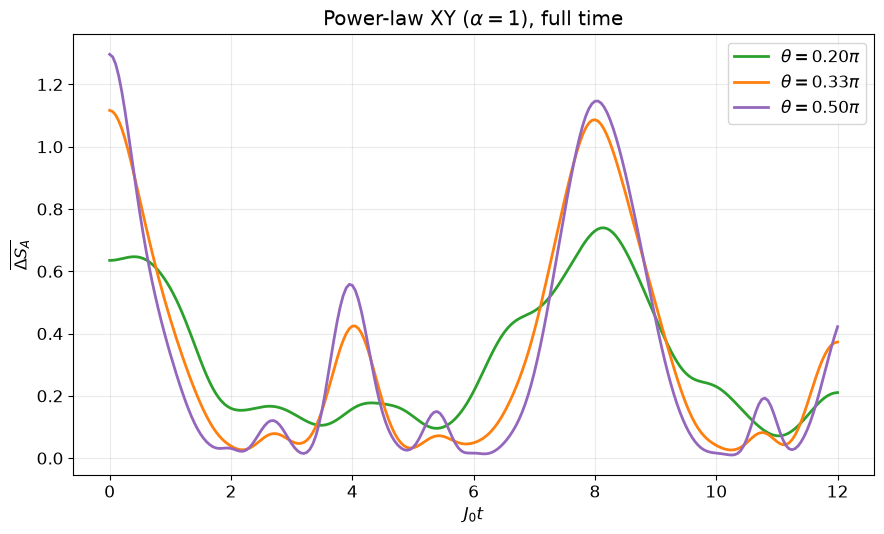

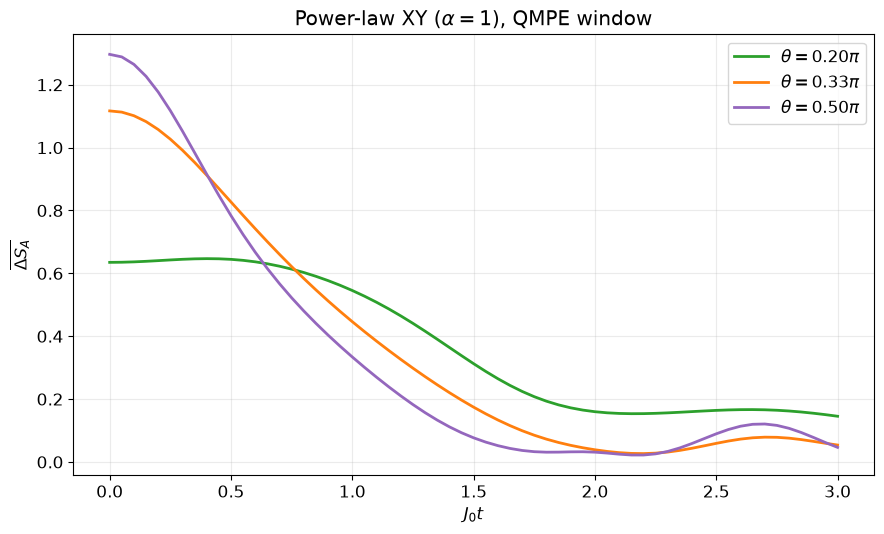

D(0)          = 0.6617
crossing time = 0.6332611906783758
crossing detector M = 0.2592


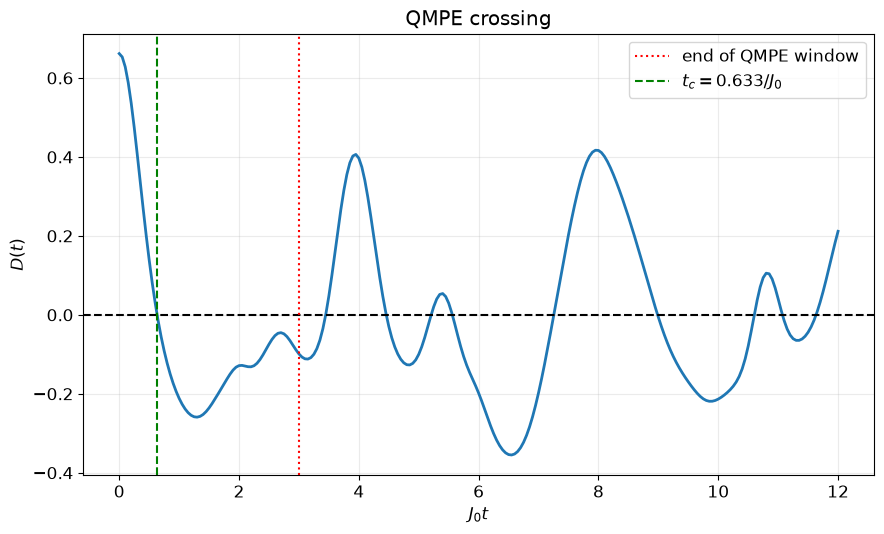

In [13]:
# ----------------------------------------------------------------------
# Entanglement asymmetry: full time and early-time QMPE window
# ----------------------------------------------------------------------
plot_EA(tlist, results_pow, tlim=t_max,
        title=r"Power-law XY ($\alpha=1$), full time")
plot_EA(tlist, results_pow, tlim=t_qmpe_max,
        title=r"Power-law XY ($\alpha=1$), QMPE window")

theta_far = thetas[-1]     # 0.50 pi  (largest initial EA)
theta_near = thetas[0]     # 0.20 pi  (smallest initial EA)

ana_pow = report_qmpe(tlist, results_pow, theta_far, theta_near,
                      t_qmpe_max, crossing_epsilon, min_negative_points)
plot_D(tlist, ana_pow, t_qmpe_max)


####  Q1:Bloch sphere :using the previous calculations,showing the symmetry restoration process


```md
## Physical Interpretation of Fig. 1(b)

Fig. 1(b) visualizes the quench dynamics of the many-body spin state through the spin-coherent-state quasidistribution

$$
Q(\vartheta,\varphi;t)
=
\left|
\langle \Psi_t
|
\mathrm{TF}(\vartheta,\varphi)
\rangle
\right|^2
$$

on the Bloch sphere.

Here, each point $(\vartheta,\varphi)$ on the sphere represents a tilted ferromagnetic (spin-coherent) state

$$
|\mathrm{TF}(\vartheta,\varphi)\rangle
=
\bigotimes_{i=1}^{N}
|\mathbf n(\vartheta,\varphi)\rangle_i,
$$

where all spins point along the same direction $\mathbf n(\vartheta,\varphi)$.

The color represents the overlap between the time-evolved many-body wavefunction $|\Psi_t\rangle$ and the corresponding tilted ferromagnetic state. Therefore, a dark-blue region indicates that the many-body state has a large overlap with a collective spin configuration pointing in that direction.

### At the Initial Time

At $t=0$, the quasidistribution is strongly localized around the direction corresponding to the initial tilted ferromagnetic state:

$$
|\Psi(0)\rangle
\approx
|\mathrm{TF}(\vartheta_0,\varphi_0)\rangle.
$$

Consequently,

$$
Q(\vartheta_0,\varphi_0;0)
$$

is close to its maximum value.

The localized blue spot therefore represents a many-body state that can be well described by a single collective spin direction.

### During the Quench Dynamics

After the quench, the state evolves according to

$$
|\Psi(t)\rangle
=
e^{-iHt}|\Psi(0)\rangle.
$$

The peak of the quasidistribution moves across the Bloch sphere, reflecting the precession of the collective magnetization.

At the same time, the distribution begins to broaden. This broadening indicates that the interacting many-body state can no longer be represented by a single tilted ferromagnetic state.

Instead, the wavefunction develops significant overlap with a range of different spin-coherent configurations.

### At Later Times

At later times, the quasidistribution becomes more diffuse and its maximum intensity decreases.

This means that

$$
\max_{\vartheta,\varphi}
Q(\vartheta,\varphi;t)
$$

becomes smaller: no single spin-coherent state provides a good description of the full many-body wavefunction.

The spreading and fading of the distribution therefore reflect the growth of many-body quantum fluctuations and correlations generated by the interacting dynamics.

---

## Important Interpretation of the Bloch Sphere

The Bloch sphere in Fig. 1(b) is **not the Bloch sphere of a single qubit**.

Instead, it parametrizes an entire family of $N$-spin coherent states:

$$
(\vartheta,\varphi)
\quad\longleftrightarrow\quad
|\mathrm{TF}(\vartheta,\varphi)\rangle.
$$

Therefore, the quasidistribution

$$
Q(\vartheta,\varphi;t)
$$

answers the question:

> **Which collective spin direction best represents the many-body state at time $t$?**

The position of the blue peak indicates the most likely collective spin direction, while the broadening and reduction of the peak indicate that the system is departing from a simple classical collective-spin description and developing genuine many-body quantum fluctuations and correlations.

In this sense, Fig. 1(b) provides more information about the many-body dynamics than simply plotting the expectation values

$$
\langle S_x(t)\rangle,\qquad
\langle S_y(t)\rangle,\qquad
\langle S_z(t)\rangle,
$$

because it visualizes not only the motion of the collective magnetization but also the spreading of the many-body wavefunction over the spin-coherent-state manifold.
```


Husimi Q grid shape (vartheta, phi, time) = (51, 100, 3)
self-check (far state theta=0.5pi, H = Stage-I H_pow):
  global max Q = 1.0000
  t = 0.0 :  max Q = 1.000   peak (vartheta = 0.50 pi, phi = 0.00 pi)
  t = 0.6 :  max Q = 0.494   peak (vartheta = 0.50 pi, phi = 0.00 pi)
  t = 2.0 :  max Q = 0.237   peak (vartheta = 0.50 pi, phi = 0.00 pi)
  t = 0.0 :  equator phi-spread (std/mean) = 1.847
  t = 0.6 :  equator phi-spread (std/mean) = 1.222
  t = 2.0 :  equator phi-spread (std/mean) = 0.443


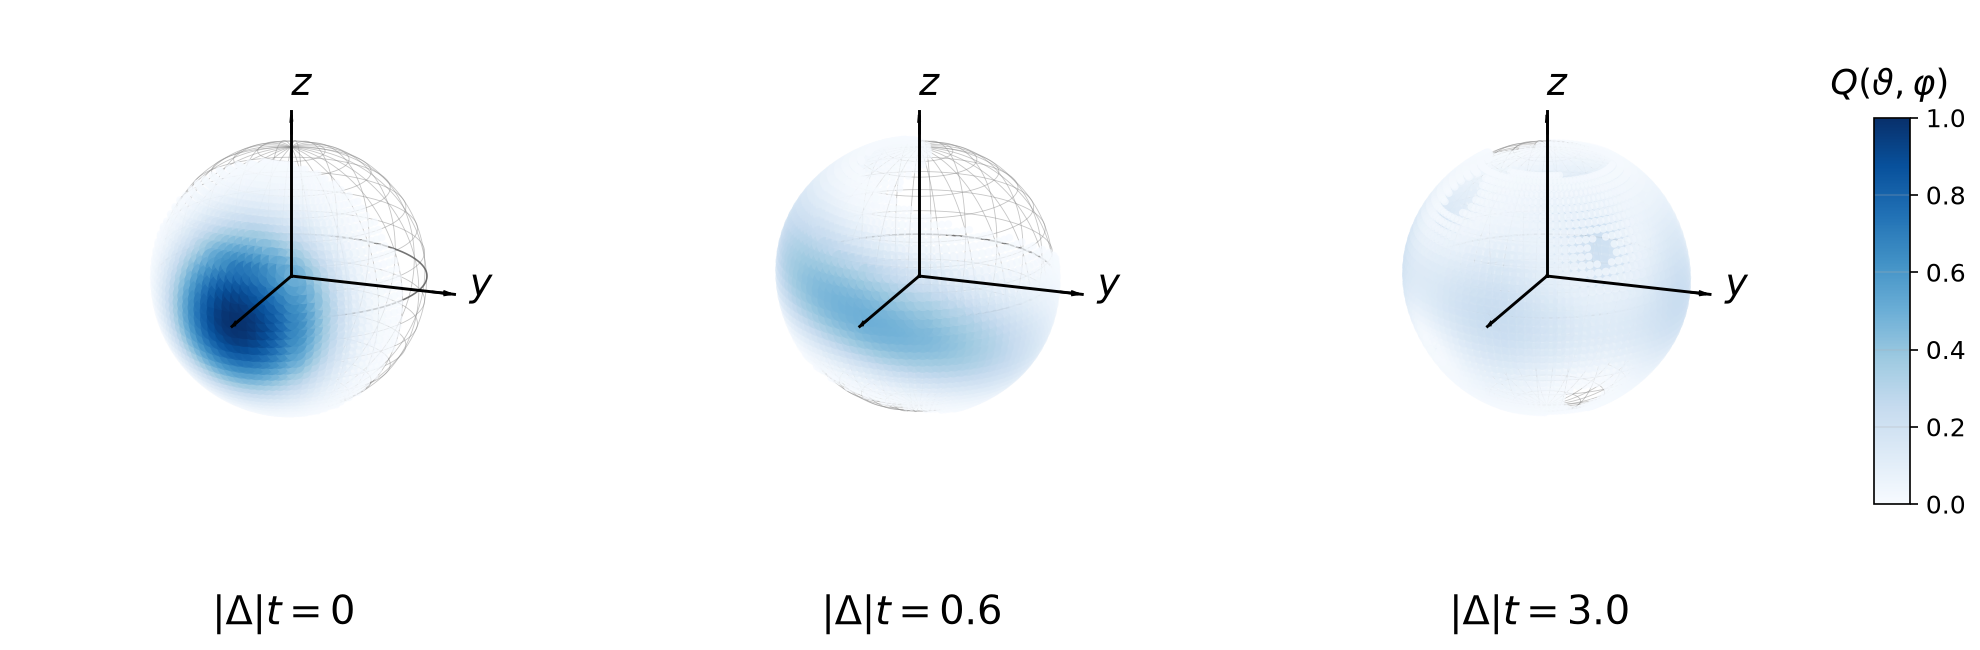

In [21]:
# ======================================================================
# Fig. 1(b)-style Husimi-Q Bloch spheres
#
# Spin-coherent-state (Husimi) quasidistribution of the many-body state:
#
#     Q(vartheta, phi; t) = |< Psi_t | TF(vartheta, phi) >|^2 ,
#
# where
#     |TF(vartheta, phi)> = tensor_i [ cos(vartheta/2) |up>
#                                     + e^{i phi} sin(vartheta/2) |down> ]
#
# is the N-spin tilted-ferromagnet (spin-coherent) state pointing along the
# unit vector  n = (sin vartheta cos phi, sin vartheta sin phi, cos vartheta).
# The three panels show the FAR tilted ferromagnet (theta = 0.5 pi, the QMPE
# protagonist) evolving under the Stage-I power-law XY Hamiltonian: the sharp
# t = 0 peak (broken U(1)) broadens and spreads over the azimuth phi (restored
# U(1) symmetry).  All three panels share ONE global normalization.
# ======================================================================

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable


# ======================================================================
# 0. Compute the Husimi Q distribution from the previous calculations
# ======================================================================

# --- time-evolved far state at the snapshot times ---------------------
# Reuses H_pow, N, thetas, tilted_product_state from the Stage-I cells.
# The tilt is a rotation ABOUT the y-axis, so at t = 0 the Bloch vector
# points along +x on the equator (vartheta = pi/2, phi = 0); U(1) restoration
# then spreads it around the z-axis (over phi).
theta_show = thetas[-1]                     # 0.50 pi  == theta_far (largest EA)
snapshot_times = np.array([0.0, 0.6, 2.0])

psi0_show = tilted_product_state(theta_show, N)
result_show = sesolve(H_pow, psi0_show, snapshot_times)
states_show = result_show.states            # list of 3 Qobj kets


def spin_coherent_state(vartheta, phi, N):
    # |TF(vartheta, phi)> pointing along n (see the cell docstring).
    psi_single = (
        np.cos(vartheta / 2.0) * up
        + np.exp(1j * phi) * np.sin(vartheta / 2.0) * down
    )
    return tensor([psi_single for _ in range(N)]).unit()


# --- polar / azimuthal grid (vartheta measured from the +z pole) ------
n_vartheta = 51
n_phi = 100
varthetas = np.linspace(0.0, np.pi, n_vartheta)      # index 25 -> pi/2
phis = np.linspace(0.0, 2.0 * np.pi, n_phi, endpoint=False)

# Q_raw[ith, iph, k] = |< TF(varthetas[ith], phis[iph]) | Psi(t_k) >|^2
Q_raw = np.zeros((n_vartheta, n_phi, len(snapshot_times)))
for ith, th in enumerate(varthetas):
    for iph, ph in enumerate(phis):
        tf = spin_coherent_state(th, ph, N)
        for k, st in enumerate(states_show):
            Q_raw[ith, iph, k] = abs(tf.overlap(st)) ** 2

print("Husimi Q grid shape (vartheta, phi, time) =", Q_raw.shape)

# --- self-check against the three acceptance criteria -----------------
print("self-check (far state theta=0.5pi, H = Stage-I H_pow):")
print("  global max Q = %.4f" % Q_raw.max())
for k in range(len(snapshot_times)):
    ith, iph = np.unravel_index(np.argmax(Q_raw[:, :, k]), (n_vartheta, n_phi))
    print("  t = %.1f :  max Q = %.3f   peak (vartheta = %.2f pi, phi = %.2f pi)"
          % (snapshot_times[k], Q_raw[:, :, k].max(),
             varthetas[ith] / np.pi, phis[iph] / np.pi))
# Equatorial azimuthal (phi) spread: large -> U(1)-broken, small -> restored.
ieq = int(np.argmin(np.abs(varthetas - np.pi / 2.0)))
for k in range(len(snapshot_times)):
    eq = Q_raw[ieq, :, k]
    print("  t = %.1f :  equator phi-spread (std/mean) = %.3f"
          % (snapshot_times[k], eq.std() / max(eq.mean(), 1e-15)))


# ======================================================================
# 1. Global physical normalization
# ======================================================================

Q_global_max = np.max(Q_raw)

Q = Q_raw / Q_global_max

norm = Normalize(0.0, 1.0)
cmap = plt.get_cmap("Blues")


# ======================================================================
# 2. Sphere coordinates and the Q-cloud radius
# ======================================================================

TH, PH = np.meshgrid(varthetas, phis, indexing="ij")

X = np.sin(TH) * np.cos(PH)
Y = np.sin(TH) * np.sin(PH)
Z = np.cos(TH)

# The Husimi-Q cloud is drawn slightly OUTSIDE the reference sphere so it can
# never be hidden by the (transparent) grid.
rQ = 1.015
XQ = rQ * X
YQ = rQ * Y
ZQ = rQ * Z

# One common, small visibility threshold for all three panels.
Q_threshold = 0.005


# ======================================================================
# 3. Transparent Bloch-sphere reference grid
# ======================================================================

def draw_grid(ax, r=1.0):
    phi_line = np.linspace(0.0, 2.0 * np.pi, 500)
    theta_line = np.linspace(0.0, np.pi, 300)

    # latitude lines
    theta_lat = np.linspace(0.08 * np.pi, 0.92 * np.pi, 15)
    for th in theta_lat:
        ax.plot(r * np.sin(th) * np.cos(phi_line),
                r * np.sin(th) * np.sin(phi_line),
                np.full_like(phi_line, r * np.cos(th)),
                color=(0.55, 0.55, 0.55), lw=0.4, alpha=0.5, zorder=1)

    # longitude lines
    phi_lon = np.linspace(0.0, 2.0 * np.pi, 24, endpoint=False)
    for ph in phi_lon:
        ax.plot(r * np.sin(theta_line) * np.cos(ph),
                r * np.sin(theta_line) * np.sin(ph),
                r * np.cos(theta_line),
                color=(0.55, 0.55, 0.55), lw=0.4, alpha=0.5, zorder=1)

    # equator (slightly darker)
    ax.plot(r * np.cos(phi_line),
            r * np.sin(phi_line),
            np.zeros_like(phi_line),
            color=(0.30, 0.30, 0.30), lw=0.8, alpha=0.7, zorder=2)


def draw_axes(ax):
    L = 1.28
    ax.plot([0, L], [0, 0], [0, 0], color="black", lw=1.4, zorder=50)
    ax.plot([0, 0], [0, L], [0, 0], color="black", lw=1.4, zorder=50)
    ax.plot([0, 0], [0, 0], [0, L], color="black", lw=1.4, zorder=50)

    ax.quiver(1.10, 0, 0, 0.15, 0, 0, color="black", linewidth=1.2,
              arrow_length_ratio=0.4)
    ax.quiver(0, 1.10, 0, 0, 0.15, 0, color="black", linewidth=1.2,
              arrow_length_ratio=0.4)
    ax.quiver(0, 0, 1.10, 0, 0, 0.15, color="black", linewidth=1.2,
              arrow_length_ratio=0.4)

    ax.text(1.40, 0, 0, r"$x$", fontsize=18)
    ax.text(0, 1.40, 0, r"$y$", fontsize=18)
    ax.text(0, 0, 1.40, r"$z$", fontsize=18)


# ======================================================================
# 4. Figure layout: three spheres + one shared colorbar
# ======================================================================

fig = plt.figure(figsize=(13.5, 4.6), dpi=150, facecolor="white")

positions = [
    [0.00, 0.15, 0.29, 0.78],   # left   t = 0
    [0.31, 0.15, 0.29, 0.78],   # middle t = 0.6
    [0.62, 0.15, 0.29, 0.78],   # right  t = 3.0
]

axes = [fig.add_axes(pos, projection="3d") for pos in positions]

time_labels = [r"$|\Delta|t=0$", r"$|\Delta|t=0.6$", r"$|\Delta|t=3.0$"]

for k, ax in enumerate(axes):
    Qk = Q[:, :, k]
    mask = Qk > Q_threshold
    qvals = Qk[mask]

    # --- Husimi-Q cloud (size grows smoothly with Q so the peak stands out) -
    s = 12.0 + 200.0 * qvals
    ax.scatter(XQ[mask], YQ[mask], ZQ[mask],
               c=qvals, cmap=cmap, vmin=0.0, vmax=1.0,
               s=s, alpha=0.7, depthshade=False,
               edgecolors="none", linewidth=0.0, zorder=10)

    # --- transparent reference sphere + axes --------------------------
    draw_grid(ax, r=1.0)
    draw_axes(ax)

    ax.set_box_aspect([1, 1, 1])
    ax.set_proj_type("ortho")
    ax.view_init(elev=18, azim=20)

    lim = 1.18
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_zlim(-lim, lim)
    ax.set_axis_off()

    # time label below the sphere
    fig.text(positions[k][0] + 0.145, 0.06, time_labels[k],
             ha="center", va="center", fontsize=19)


# ======================================================================
# 5. Shared colorbar
# ======================================================================

cax = fig.add_axes([0.93, 0.22, 0.018, 0.56])
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_ticks(np.linspace(0.0, 1.0, 6))
cbar.ax.tick_params(labelsize=12, width=0.8, length=4)
fig.text(0.938, 0.80, r"$Q(\vartheta,\varphi)$", ha="center", va="bottom",
         fontsize=17)


# ======================================================================
# 6. Final rendering
# ======================================================================

plt.show()
 


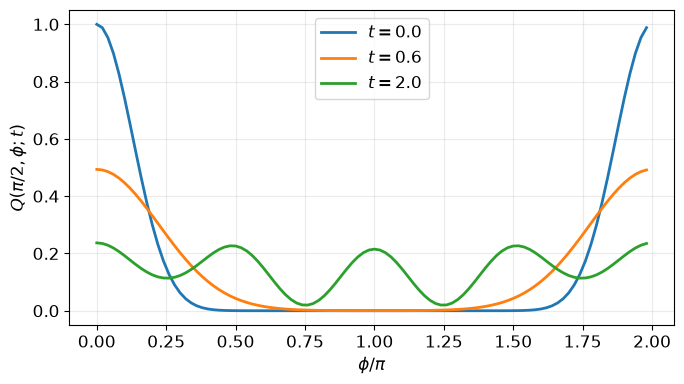

In [22]:
ieq = np.argmin(
    np.abs(varthetas - np.pi/2)
)

plt.figure(figsize=(7,4))

for k, t in enumerate(snapshot_times):

    plt.plot(
        phis / np.pi,
        Q_raw[ieq,:,k],
        lw=2,
        label=rf"$t={t}$"
    )

plt.xlabel(r"$\phi/\pi$")
plt.ylabel(
    r"$Q(\pi/2,\phi;t)$"
)

plt.legend()
plt.tight_layout()
plt.show()

Best visually uniform time:
    t* = 3.2000
    anisotropy = 0.404096
    mean equatorial Q = 0.143173
    max equatorial Q = 0.212838
    min equatorial Q = 0.020712


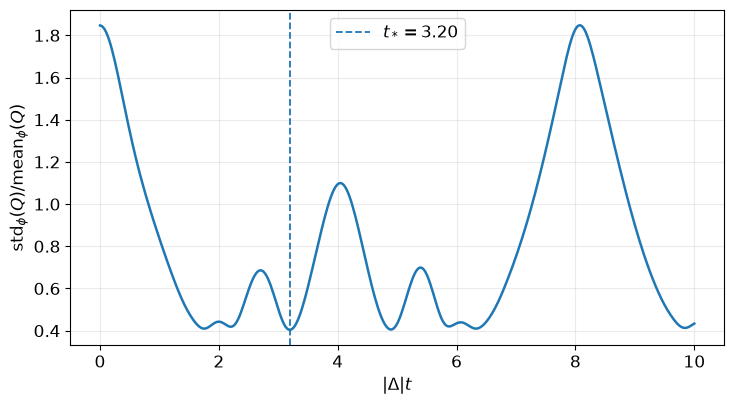

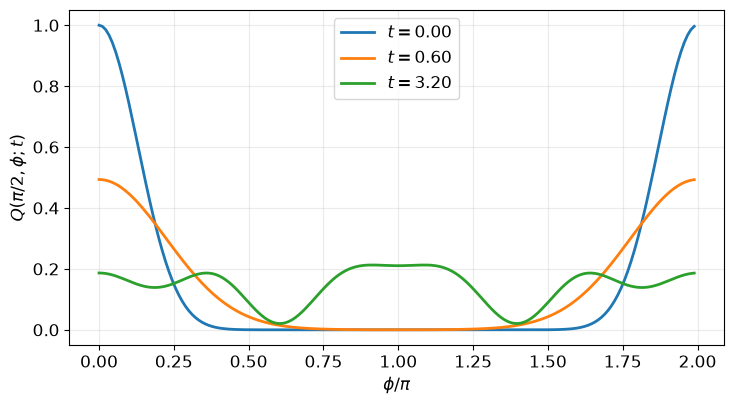

In [16]:
# ======================================================================
# Search for the time at which the Husimi-Q distribution is most
# azimuthally uniform around the z axis.
#
# Initial state:
#       theta_show = 0.5*pi
#
# Criterion:
#
#       A(t) = std_phi[Q(pi/2,phi;t)]
#              -----------------------
#              mean_phi[Q(pi/2,phi;t)]
#
# Smaller A(t) -> more uniform around z.
# ======================================================================

import numpy as np
import matplotlib.pyplot as plt
from qutip import sesolve


# ======================================================================
# 1. Dense time scan
# ======================================================================

theta_show = thetas[-1]

psi0_show = tilted_product_state(
    theta_show,
    N
)

# Scan substantially beyond t=3 because finite-size unitary dynamics
# may reach its most uniform configuration at another time.
t_scan = np.linspace(
    0.0,
    10.0,
    401
)


# ======================================================================
# 2. Actual unitary dynamics
# ======================================================================

result_scan = sesolve(
    H_pow,
    psi0_show,
    t_scan
)


# ======================================================================
# 3. We only need coherent states on the equator
#
# vartheta = pi/2
# ======================================================================

n_phi_search = 180

phi_search = np.linspace(
    0.0,
    2.0*np.pi,
    n_phi_search,
    endpoint=False
)


equator_states = [

    spin_coherent_state(
        np.pi/2,
        phi,
        N
    )

    for phi in phi_search
]


# ======================================================================
# 4. Q(pi/2, phi; t)
# ======================================================================

Q_equator_scan = np.zeros(
    (
        len(t_scan),
        n_phi_search
    )
)


for it, psi_t in enumerate(result_scan.states):

    for ip, tf in enumerate(equator_states):

        Q_equator_scan[it, ip] = (
            abs(tf.overlap(psi_t))**2
        )


# ======================================================================
# 5. Normalize globally ONLY for visualization
#
# The anisotropy ratio below is invariant under an overall scale.
# ======================================================================

Q_scan_global_max = np.max(
    Q_equator_scan
)

Qeq = (
    Q_equator_scan
    /
    Q_scan_global_max
)


# ======================================================================
# 6. Azimuthal anisotropy
# ======================================================================

mean_phi = np.mean(
    Qeq,
    axis=1
)

std_phi = np.std(
    Qeq,
    axis=1
)

anisotropy = (
    std_phi
    /
    np.maximum(
        mean_phi,
        1e-14
    )
)


# ======================================================================
# 7. Visibility condition
#
# Avoid selecting a mathematically uniform time where the entire
# coherent-state overlap is essentially zero.
#
# Require the mean equatorial Q to retain at least 5% of its maximum
# value during the scan.
# ======================================================================

visibility_fraction = 0.05

visible = (
    mean_phi
    >
    visibility_fraction
    * np.max(mean_phi)
)


score = anisotropy.copy()

score[~visible] = np.inf


# Ignore t=0 automatically
score[t_scan < 0.1] = np.inf


# ======================================================================
# 8. Best time
# ======================================================================

i_best = np.argmin(score)

t_best = t_scan[i_best]


print(
    "Best visually uniform time:"
)

print(
    f"    t* = {t_best:.4f}"
)

print(
    f"    anisotropy = "
    f"{anisotropy[i_best]:.6f}"
)

print(
    f"    mean equatorial Q = "
    f"{mean_phi[i_best]:.6f}"
)

print(
    f"    max equatorial Q = "
    f"{Qeq[i_best].max():.6f}"
)

print(
    f"    min equatorial Q = "
    f"{Qeq[i_best].min():.6f}"
)


# ======================================================================
# 9. Plot anisotropy versus time
# ======================================================================

plt.figure(
    figsize=(7.5, 4.2)
)

plt.plot(
    t_scan,
    anisotropy,
    lw=1.8
)

plt.axvline(
    t_best,
    ls="--",
    lw=1.3,
    label=rf"$t_*={t_best:.2f}$"
)

plt.xlabel(
    r"$|\Delta|t$"
)

plt.ylabel(
    r"$\mathrm{std}_{\phi}(Q)/"
    r"\mathrm{mean}_{\phi}(Q)$"
)

plt.legend()

plt.tight_layout()
plt.show()


# ======================================================================
# 10. Compare several equatorial distributions
# ======================================================================

comparison_times = [
    0.0,
    0.6,
    t_best
]


plt.figure(
    figsize=(7.5, 4.2)
)


for t_target in comparison_times:

    idx = np.argmin(
        np.abs(
            t_scan - t_target
        )
    )

    plt.plot(
        phi_search / np.pi,
        Qeq[idx],
        lw=2,
        label=rf"$t={t_scan[idx]:.2f}$"
    )


plt.xlabel(
    r"$\phi/\pi$"
)

plt.ylabel(
    r"$Q(\pi/2,\phi;t)$"
)

plt.legend()

plt.tight_layout()
plt.show()

Final snapshot times:
    t = 0.0000
    t = 0.6000
    t = 2.0000

Computing full Husimi-Q distributions...

Husimi-Q diagnostics:

t = 0.0000
    max Q = 1.00000000
    peak vartheta/pi = 0.5000
    peak phi/pi = 0.0000
    ||Psi||^2 = 1.000000000000

t = 0.6000
    max Q = 0.49350308
    peak vartheta/pi = 0.5000
    peak phi/pi = 0.0000
    ||Psi||^2 = 1.000000000000

t = 2.0000
    max Q = 0.23694101
    peak vartheta/pi = 0.5000
    peak phi/pi = 0.0000
    ||Psi||^2 = 1.000000000000

Equatorial azimuthal anisotropy:
    t=0.0000: std/mean = 1.846606
    t=0.6000: std/mean = 1.222488
    t=2.0000: std/mean = 0.442636

Physical Q shape: (61, 144, 3)
Closed plotting Q shape: (61, 145, 3)


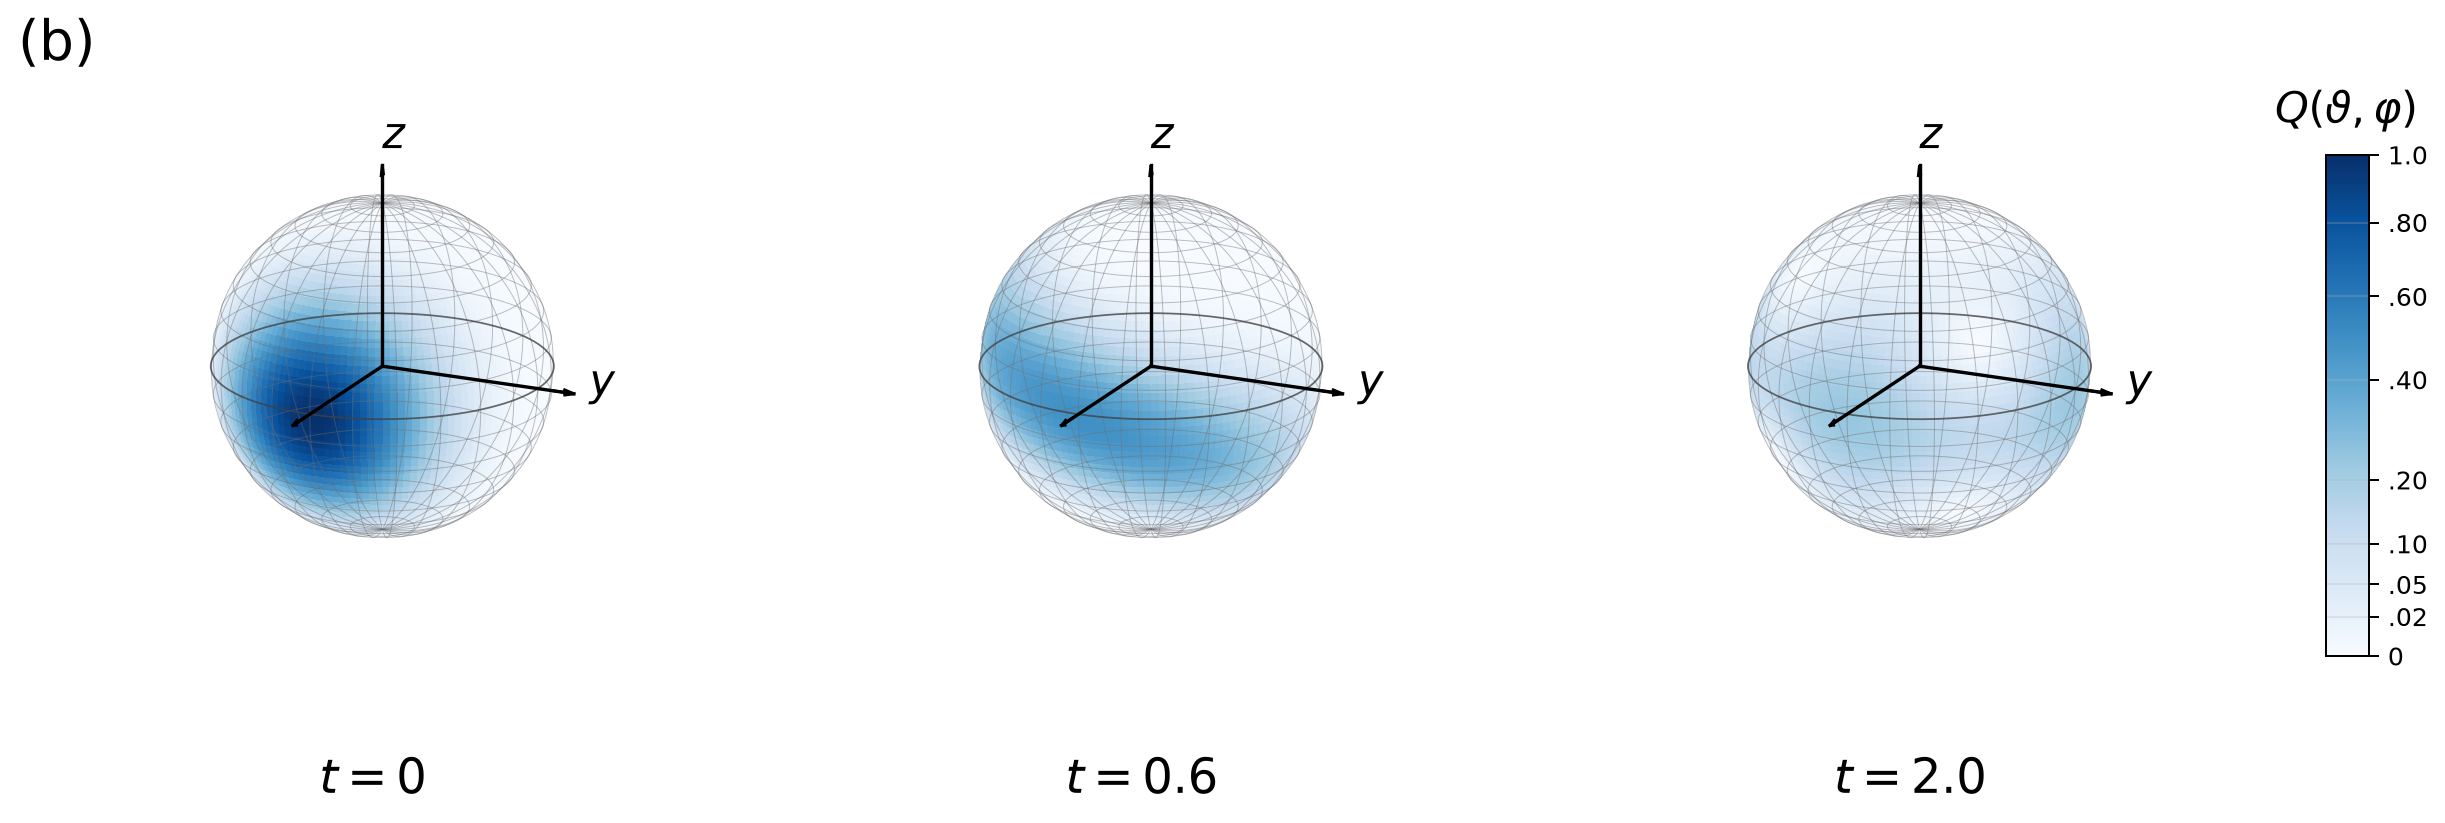

In [20]:
# ======================================================================
# FINAL CLOSED-MESH Fig. 1(b)-STYLE HUSIMI-Q BLOCH SPHERES
#
# Requires:
#     H_pow
#     N
#     t_best
#     psi0_show
#     spin_coherent_state(...)
#
# Physical quantity:
#
#     Q(vartheta, phi; t)
#       = |<TF(vartheta,phi)|Psi(t)>|^2
#
# Important:
#   - real Stage-I unitary dynamics
#   - theta_show = 0.5*pi
#   - ONE global normalization
#   - no per-panel normalization
#   - no artificial smoothing
#   - periodic phi direction is explicitly CLOSED only for rendering
# ======================================================================


import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import PowerNorm
from matplotlib.cm import ScalarMappable
from qutip import sesolve


# ======================================================================
# 1. Final snapshot times
# ======================================================================

snapshot_times_final = np.array(
    [
        0.0,
        0.6,
        2.0
    ],
    dtype=float
)

print("Final snapshot times:")

for t in snapshot_times_final:
    print(f"    t = {t:.4f}")


# ======================================================================
# 2. Actual Stage-I dynamics
# ======================================================================

result_final = sesolve(
    H_pow,
    psi0_show,
    snapshot_times_final
)

states_final = result_final.states


# ======================================================================
# 3. Angular grid for physical Q calculation
#
# IMPORTANT:
#
# endpoint=False is physically correct because
#
#     phi = 0
#
# and
#
#     phi = 2*pi
#
# represent the same state.
# ======================================================================

n_vartheta_final = 61
n_phi_final = 144

varthetas_final = np.linspace(
    0.0,
    np.pi,
    n_vartheta_final
)

phis_final = np.linspace(
    0.0,
    2.0*np.pi,
    n_phi_final,
    endpoint=False
)


# ======================================================================
# 4. Compute full physical Husimi-Q
# ======================================================================

Q_final_raw = np.zeros(
    (
        n_vartheta_final,
        n_phi_final,
        len(snapshot_times_final)
    ),
    dtype=float
)


print("\nComputing full Husimi-Q distributions...")


for ith, vartheta in enumerate(varthetas_final):

    for iph, phi in enumerate(phis_final):

        tf = spin_coherent_state(
            vartheta,
            phi,
            N
        )

        for k, psi_t in enumerate(states_final):

            Q_final_raw[
                ith,
                iph,
                k
            ] = abs(
                tf.overlap(psi_t)
            )**2


# ======================================================================
# 5. Diagnostics
# ======================================================================

print("\nHusimi-Q diagnostics:")


for k, t in enumerate(snapshot_times_final):

    Qk = Q_final_raw[:, :, k]

    ith_max, iph_max = np.unravel_index(
        np.argmax(Qk),
        Qk.shape
    )

    print(
        f"\nt = {t:.4f}"
    )

    print(
        f"    max Q = "
        f"{Qk.max():.8f}"
    )

    print(
        f"    peak vartheta/pi = "
        f"{varthetas_final[ith_max]/np.pi:.4f}"
    )

    print(
        f"    peak phi/pi = "
        f"{phis_final[iph_max]/np.pi:.4f}"
    )

    print(
        f"    ||Psi||^2 = "
        f"{states_final[k].norm()**2:.12f}"
    )


# ======================================================================
# 6. Equatorial anisotropy diagnostic
# ======================================================================

ieq = np.argmin(
    np.abs(
        varthetas_final
        - np.pi/2
    )
)


print("\nEquatorial azimuthal anisotropy:")


for k, t in enumerate(snapshot_times_final):

    eq = Q_final_raw[
        ieq,
        :,
        k
    ]

    anisotropy = (
        np.std(eq)
        /
        max(
            np.mean(eq),
            1e-15
        )
    )

    print(
        f"    t={t:.4f}: "
        f"std/mean = {anisotropy:.6f}"
    )


# ======================================================================
# 7. GLOBAL physical normalization
#
# ONE scale for all three panels.
# ======================================================================

Q_global_max = np.max(
    Q_final_raw
)

Q_final = (
    Q_final_raw
    /
    Q_global_max
)


# ======================================================================
# 8. Display mapping
#
# gamma < 1 enhances weak Q.
#
# Previous gamma ~ 0.38 was too aggressive and visually broadened
# very weak tails.
#
# gamma = 0.65 is deliberately more conservative.
# ======================================================================

gamma_display = 0.65

norm_display = PowerNorm(
    gamma=gamma_display,
    vmin=0.0,
    vmax=1.0
)

cmap = plt.get_cmap(
    "Blues"
)


# ======================================================================
# 9. CRITICAL FIX: explicitly close periodic phi direction
#
# Physical calculation:
#
#     phi = [0, ..., < 2*pi]
#
# Rendering:
#
#     append phi = 2*pi
#
# and copy the phi=0 Q column to phi=2*pi.
#
# Therefore:
#
#     Q(vartheta, 2*pi)
#       = Q(vartheta, 0)
#
# exactly.
#
# This closes the plot_surface mesh and removes the artificial
# longitudinal white seam.
# ======================================================================

phis_plot = np.concatenate(
    [
        phis_final,
        np.array([2.0*np.pi])
    ]
)


Q_plot_closed = np.concatenate(
    [
        Q_final,

        # Copy phi = 0 column
        Q_final[:, 0:1, :]
    ],
    axis=1
)


print(
    "\nPhysical Q shape:",
    Q_final.shape
)

print(
    "Closed plotting Q shape:",
    Q_plot_closed.shape
)


# ======================================================================
# 10. Closed spherical mesh
# ======================================================================

TH_plot, PH_plot = np.meshgrid(
    varthetas_final,
    phis_plot,
    indexing="ij"
)


X_plot = (
    np.sin(TH_plot)
    * np.cos(PH_plot)
)

Y_plot = (
    np.sin(TH_plot)
    * np.sin(PH_plot)
)

Z_plot = np.cos(
    TH_plot
)


# ======================================================================
# 11. Bloch-sphere reference grid
#
# Grid is slightly outside the Q surface.
# ======================================================================

def draw_bloch_grid(
    ax,
    r=1.006
):

    phi_line = np.linspace(
        0.0,
        2.0*np.pi,
        600
    )

    theta_line = np.linspace(
        0.0,
        np.pi,
        500
    )


    # ------------------------------------------------------------------
    # Latitudes
    # ------------------------------------------------------------------

    theta_lat = np.linspace(
        0.06*np.pi,
        0.94*np.pi,
        17
    )


    for theta0 in theta_lat:

        xg = (
            r
            * np.sin(theta0)
            * np.cos(phi_line)
        )

        yg = (
            r
            * np.sin(theta0)
            * np.sin(phi_line)
        )

        zg = np.full_like(
            phi_line,
            r*np.cos(theta0)
        )


        ax.plot(
            xg,
            yg,
            zg,

            color="0.43",

            lw=0.38,

            alpha=0.45,

            zorder=20
        )


    # ------------------------------------------------------------------
    # Longitudes
    # ------------------------------------------------------------------

    phi_lon = np.linspace(
        0.0,
        2.0*np.pi,
        24,
        endpoint=False
    )


    for phi0 in phi_lon:

        xg = (
            r
            * np.sin(theta_line)
            * np.cos(phi0)
        )

        yg = (
            r
            * np.sin(theta_line)
            * np.sin(phi0)
        )

        zg = (
            r
            * np.cos(theta_line)
        )


        ax.plot(
            xg,
            yg,
            zg,

            color="0.43",

            lw=0.38,

            alpha=0.45,

            zorder=20
        )


    # ------------------------------------------------------------------
    # Equator
    # ------------------------------------------------------------------

    ax.plot(
        r*np.cos(phi_line),

        r*np.sin(phi_line),

        np.zeros_like(phi_line),

        color="0.23",

        lw=0.72,

        alpha=0.68,

        zorder=21
    )


# ======================================================================
# 12. Coordinate axes
# ======================================================================

def draw_coordinate_axes(ax):

    L = 1.24


    # ------------------------------------------------------------------
    # x axis
    # ------------------------------------------------------------------

    ax.plot(
        [0, L],
        [0, 0],
        [0, 0],

        color="black",

        lw=1.35,

        zorder=50
    )


    # ------------------------------------------------------------------
    # y axis
    # ------------------------------------------------------------------

    ax.plot(
        [0, 0],
        [0, L],
        [0, 0],

        color="black",

        lw=1.35,

        zorder=50
    )


    # ------------------------------------------------------------------
    # z axis
    # ------------------------------------------------------------------

    ax.plot(
        [0, 0],
        [0, 0],
        [0, L],

        color="black",

        lw=1.35,

        zorder=50
    )


    # ------------------------------------------------------------------
    # Arrowheads
    # ------------------------------------------------------------------

    ax.quiver(
        1.07, 0, 0,

        0.17, 0, 0,

        color="black",

        linewidth=1.15,

        arrow_length_ratio=0.42
    )


    ax.quiver(
        0, 1.07, 0,

        0, 0.17, 0,

        color="black",

        linewidth=1.15,

        arrow_length_ratio=0.42
    )


    ax.quiver(
        0, 0, 1.07,

        0, 0, 0.17,

        color="black",

        linewidth=1.15,

        arrow_length_ratio=0.42
    )


    # ------------------------------------------------------------------
    # Labels
    # ------------------------------------------------------------------

    ax.text(
        1.34,
        0,
        0,

        r"$x$",

        fontsize=17
    )


    ax.text(
        0,
        1.34,
        0,

        r"$y$",

        fontsize=17
    )


    ax.text(
        0,
        0,
        1.34,

        r"$z$",

        fontsize=17
    )


# ======================================================================
# 13. Figure layout
# ======================================================================

fig = plt.figure(
    figsize=(14.0, 4.8),
    dpi=180,
    facecolor="white"
)


positions = [

    [0.010, 0.16, 0.290, 0.77],

    [0.315, 0.16, 0.290, 0.77],

    [0.620, 0.16, 0.290, 0.77],

]


axes = [

    fig.add_axes(
        position,
        projection="3d"
    )

    for position in positions
]


# ======================================================================
# 14. Render closed Husimi-Q surfaces
# ======================================================================

for k, ax in enumerate(axes):


    # ------------------------------------------------------------------
    # IMPORTANT:
    #
    # Use the CLOSED Q array here.
    # ------------------------------------------------------------------

    Qk = Q_plot_closed[
        :,
        :,
        k
    ]


    # ==================================================================
    # Q -> displayed color
    # ==================================================================

    colors = cmap(
        norm_display(Qk)
    )


    # ==================================================================
    # CRITICAL:
    #
    # NO per-face transparency.
    #
    # Low Q -> white via colormap.
    #
    # This avoids alpha-sorting cracks.
    # ==================================================================

    colors[..., 3] = 1.0


    # ==================================================================
    # CLOSED surface
    # ==================================================================

    ax.plot_surface(

        X_plot,
        Y_plot,
        Z_plot,

        facecolors=colors,

        # Use every face
        rstride=1,
        cstride=1,

        # No polygon borders
        linewidth=0,

        edgecolor="none",

        # Avoid antialiasing gaps between adjacent polygons
        antialiased=False,

        shade=False,

        zorder=5
    )


    # ==================================================================
    # Reference grid
    # ==================================================================

    draw_bloch_grid(
        ax,
        r=1.006
    )


    # ==================================================================
    # Coordinate axes
    # ==================================================================

    draw_coordinate_axes(
        ax
    )


    # ==================================================================
    # Geometry
    # ==================================================================

    ax.set_box_aspect(
        [1, 1, 1]
    )


    ax.set_proj_type(
        "ortho"
    )


    # Same camera for all three panels
    ax.view_init(
        elev=18,
        azim=25
    )


    lim = 1.16


    ax.set_xlim(
        -lim,
        lim
    )

    ax.set_ylim(
        -lim,
        lim
    )

    ax.set_zlim(
        -lim,
        lim
    )


    ax.set_axis_off()


# ======================================================================
# 15. Time labels
# ======================================================================

time_labels = [

    r"$ t=0$",

    r"$ t=0.6$",

    rf"$ t=2.0$"

]


for k, label in enumerate(time_labels):

    fig.text(

        positions[k][0]
        +
        positions[k][2]/2,

        0.075,

        label,

        ha="center",

        va="center",

        fontsize=19
    )


# ======================================================================
# 16. Panel label
# ======================================================================

fig.text(
    0.014,
    0.91,

    r"(b)",

    fontsize=22
)


# ======================================================================
# 17. Shared colorbar
#
# PowerNorm changes only Q -> displayed color.
#
# Tick labels remain actual normalized physical Q values.
# ======================================================================

cax = fig.add_axes(
    [
        0.930,
        0.22,
        0.017,
        0.58
    ]
)


sm = ScalarMappable(
    cmap=cmap,
    norm=norm_display
)

sm.set_array([])


cbar = fig.colorbar(
    sm,
    cax=cax
)


physical_ticks = np.array(
    [
        0.00,
        0.02,
        0.05,
        0.10,
        0.20,
        0.40,
        0.60,
        0.80,
        1.00
    ]
)


cbar.set_ticks(
    physical_ticks
)


cbar.set_ticklabels(
    [
        "0",
        ".02",
        ".05",
        ".10",
        ".20",
        ".40",
        ".60",
        ".80",
        "1.0"
    ]
)


cbar.ax.tick_params(
    labelsize=10,
    width=0.8,
    length=4
)


# ======================================================================
# 18. Colorbar title
# ======================================================================

fig.text(
    0.938,
    0.825,

    r"$Q(\vartheta,\varphi)$",

    ha="center",

    va="bottom",

    fontsize=17
)


# ======================================================================
# 19. Final rendering
# ======================================================================

plt.show()

In [18]:
# ----------------------------------------------------------------------
# Stage I -- scan over the power-law exponent alpha
# ----------------------------------------------------------------------
alphas = [0.5, 1.0, 1.5, 2.0, 3.0]

alpha_scan = []
for a in alphas:
    J = coupling_powerlaw(N, J0, a)
    H = build_XY(N, J, h_zero, Sx, Sy, Sz)
    res = run_quench(H, thetas, tlist, subsystems, charge_projectors, N)
    ana = qmpe_crossing(tlist, res[theta_far]["EA_mean"],
                        res[theta_near]["EA_mean"],
                        t_qmpe_max, crossing_epsilon, min_negative_points)
    alpha_scan.append((rf"$\alpha={a:.1f}$",
                       res[theta_near]["EA_mean"],
                       res[theta_far]["EA_mean"], ana["tcross"]))
    print(f"alpha = {a:.1f}:  t_cross = {ana['tcross']}"
          f"  (crossing detector M = {ana['strength']:.4f})")

# The QMPE is read off directly from the Delta S_A(t) curves: as alpha grows
# the far curve dips below the near curve inside the early window.
plot_EA_grid(alpha_scan, tlist, tlim=t_qmpe_max,
             suptitle=r"$\Delta S_A(t)$ vs power-law exponent $\alpha$ (QMPE window)")


KeyboardInterrupt: 

N = 8:  t_cross = 0.7106855628851059  (crossing detector M = 0.2350)
N = 10:  t_cross = 0.6535806990842976  (crossing detector M = 0.2583)
N = 12:  t_cross = 0.6332611906783758  (crossing detector M = 0.2592)
N = 14:  t_cross = 0.6285547136807402  (crossing detector M = 0.2565)


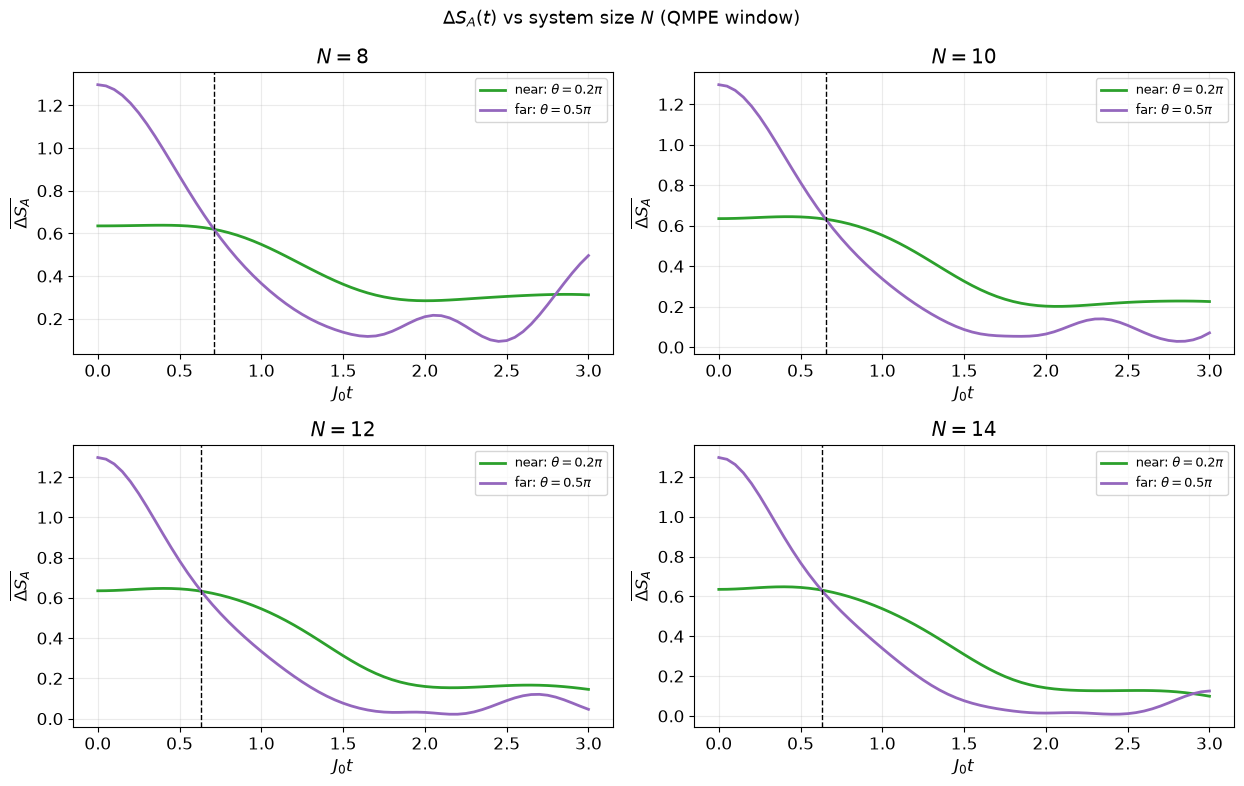

In [ ]:
# ----------------------------------------------------------------------
# Stage I -- finite-size scan (paper SM: QMPE weakens for smaller N)
# ----------------------------------------------------------------------
Ns = [ 8, 10, 12,14]  # paper: N = 8, 10, 12, 14, 16

N_scan = []
for Nn in Ns:
    Sx_n, Sy_n, Sz_n = build_spin_ops(Nn)
    J_n = coupling_powerlaw(Nn, J0, 1.0)
    H_n = build_XY(Nn, J_n, np.zeros(Nn), Sx_n, Sy_n, Sz_n)
    subs_n = list(combinations(central_sites_for_N(Nn, n_central), NA))
    res_n = run_quench(H_n, thetas, tlist, subs_n, charge_projectors, Nn)
    ana_n = qmpe_crossing(tlist, res_n[theta_far]["EA_mean"],
                          res_n[theta_near]["EA_mean"],
                          t_qmpe_max, crossing_epsilon, min_negative_points)
    N_scan.append((f"$N={Nn}$",
                   res_n[theta_near]["EA_mean"],
                   res_n[theta_far]["EA_mean"], ana_n["tcross"]))
    print(f"N = {Nn}:  t_cross = {ana_n['tcross']}"
          f"  (crossing detector M = {ana_n['strength']:.4f})")

plot_EA_grid(N_scan, tlist, tlim=t_qmpe_max,
             suptitle=r"$\Delta S_A(t)$ vs system size $N$ (QMPE window)")


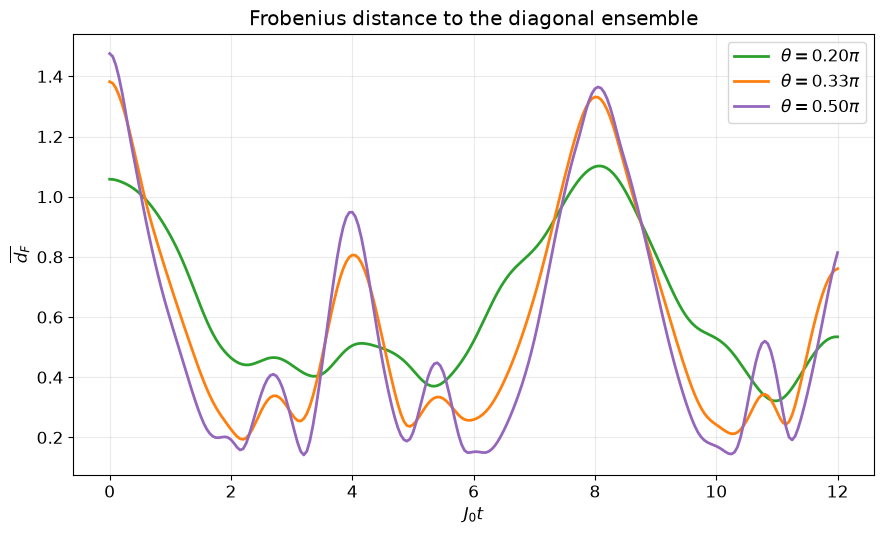

Frobenius QMPE:  t_cross = 0.5129136126017906   (crossing detector M = 0.3644 )


In [ ]:
# ----------------------------------------------------------------------
# Stage I -- Frobenius distance to the diagonal ensemble (paper Fig. 4)
# ----------------------------------------------------------------------
results_pow_F = run_quench(H_pow, thetas, tlist, subsystems,
                           charge_projectors, N, frobenius=True)

plt.figure()
for t in thetas:
    plt.plot(tlist, results_pow_F[t]["dF_mean"],
             color=theta_colors[t], lw=2, label=theta_labels[t])
plt.xlabel(r"$J_0 t$")
plt.ylabel(r"$\overline{d_F}$")
plt.title("Frobenius distance to the diagonal ensemble")
plt.legend()
plt.tight_layout()
plt.show()

# QMPE read-out from the Frobenius distance (far - near)
ana_F = qmpe_crossing(tlist, results_pow_F[theta_far]["dF_mean"],
                      results_pow_F[theta_near]["dF_mean"],
                      t_qmpe_max, crossing_epsilon, min_negative_points)
print("Frobenius QMPE:  t_cross =", ana_F["tcross"],
      "  (crossing detector M =", round(ana_F["strength"], 4), ")")


---
## Stage II -- Exponential XY: shortening the range closes the QMPE

Coupling $J_{ij}=J_0\,e^{-|i-j|/\xi}$. Scanning the correlation length
$\xi$ tests whether a shorter interaction range suppresses the QMPE.


xi = 0.3:  t_cross = 1.141161143998214  (crossing detector M = 0.4739)
xi = 0.5:  t_cross = 1.067149751459011  (crossing detector M = 0.4609)
xi = 0.8:  t_cross = 0.935557687205447  (crossing detector M = 0.4342)
xi = 1.0:  t_cross = 0.8534712939952402  (crossing detector M = 0.4094)
xi = 1.5:  t_cross = 0.6972891964396293  (crossing detector M = 0.3368)
xi = 2.0:  t_cross = 0.6008664862227571  (crossing detector M = 0.2821)


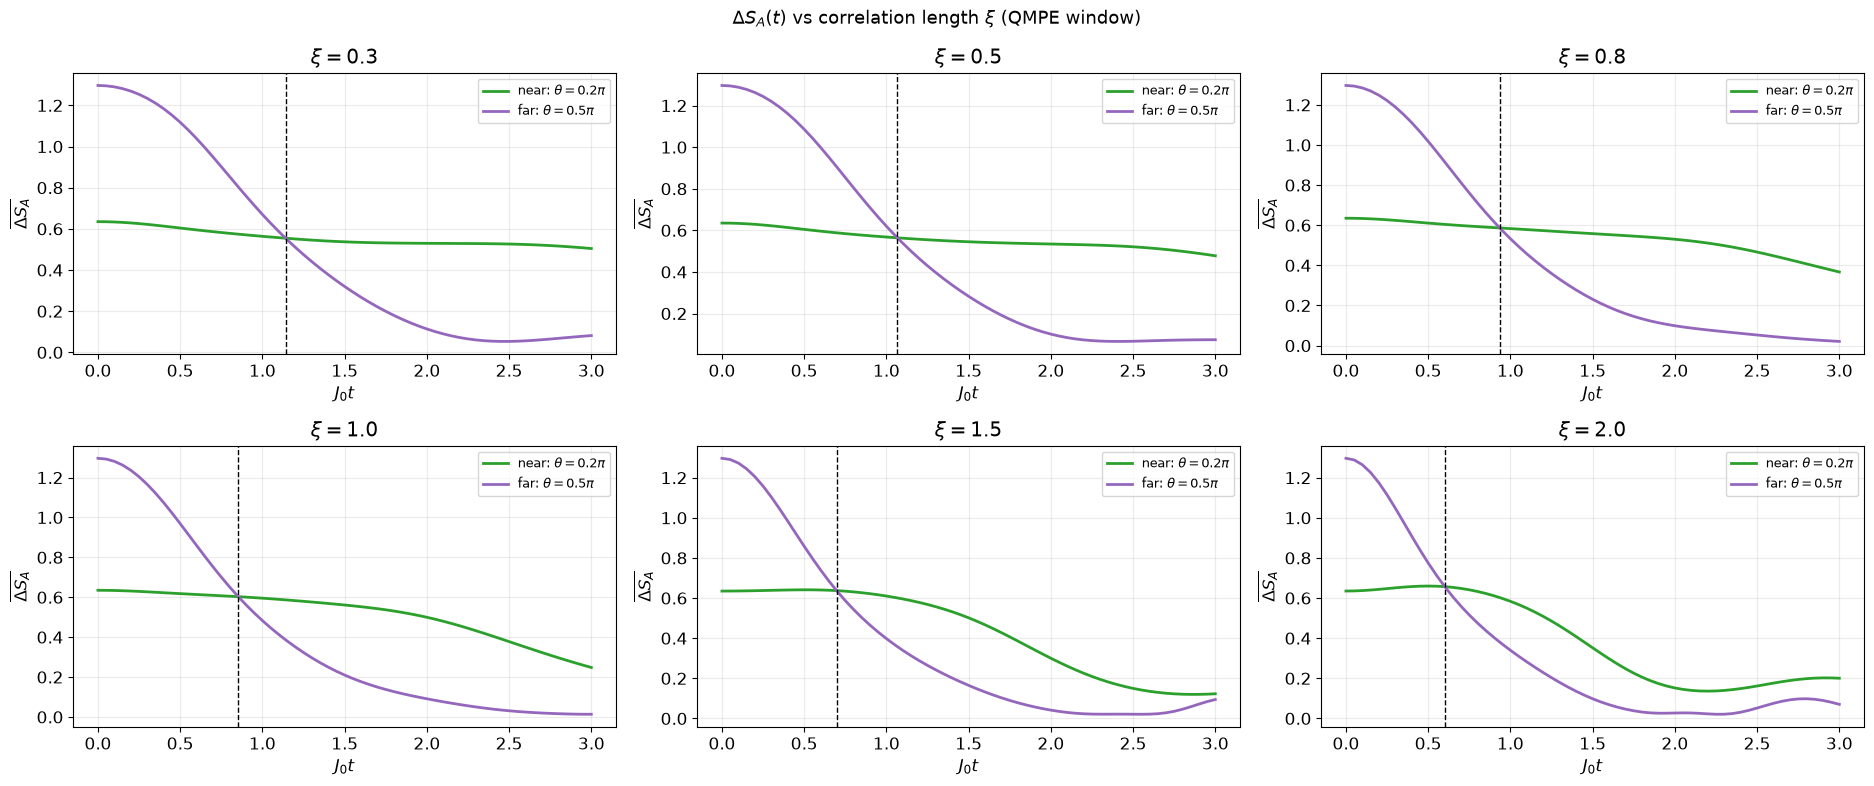

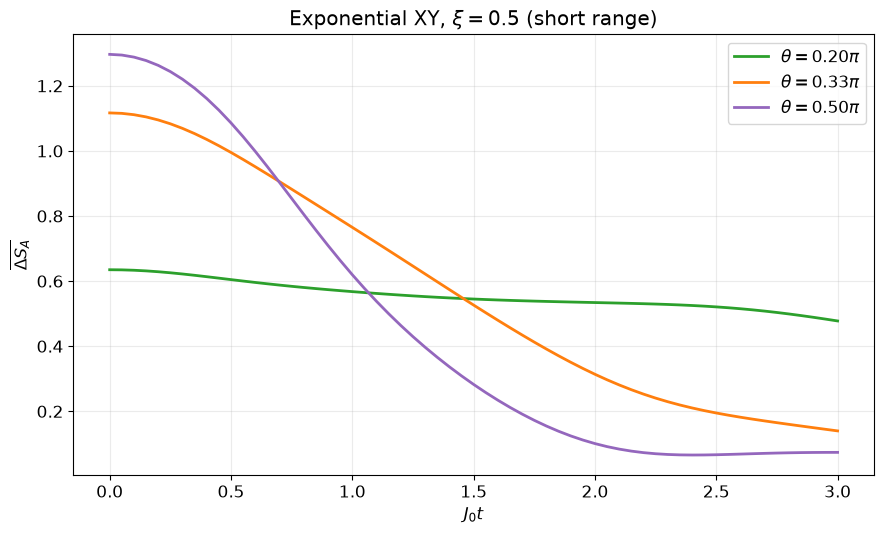

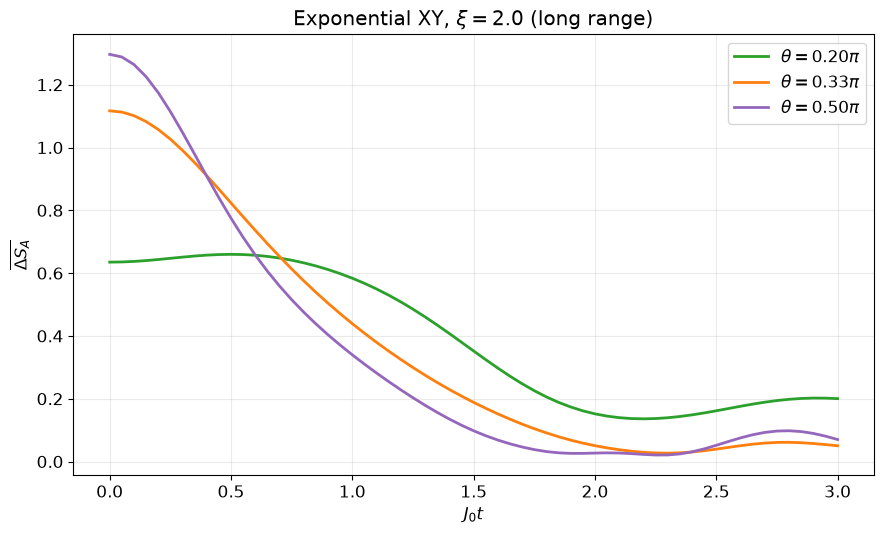

In [ ]:
# ----------------------------------------------------------------------
# Stage II -- scan over the exponential correlation length xi
# ----------------------------------------------------------------------
xis = [0.3, 0.5, 0.8, 1.0, 1.5, 2.0]

xi_summary = {}
xi_scan = []
for xi in xis:
    J = coupling_exponential(N, J0, xi)
    H = build_XY(N, J, h_zero, Sx, Sy, Sz)
    res = run_quench(H, thetas, tlist, subsystems, charge_projectors, N)
    ana = qmpe_crossing(tlist, res[theta_far]["EA_mean"],
                        res[theta_near]["EA_mean"],
                        t_qmpe_max, crossing_epsilon, min_negative_points)
    xi_summary[xi] = (res, ana)
    xi_scan.append((rf"$\xi={xi:.1f}$",
                    res[theta_near]["EA_mean"],
                    res[theta_far]["EA_mean"], ana["tcross"]))
    print(f"xi = {xi:.1f}:  t_cross = {ana['tcross']}"
          f"  (crossing detector M = {ana['strength']:.4f})")

# Shortening xi suppresses the crossing: read directly from Delta S_A(t).
plot_EA_grid(xi_scan, tlist, tlim=t_qmpe_max, ncols=3,
             suptitle=r"$\Delta S_A(t)$ vs correlation length $\xi$ (QMPE window)")

# Compare a short-range and a long-range case side by side.
plot_EA(tlist, xi_summary[0.5][0], tlim=t_qmpe_max,
        title=r"Exponential XY, $\xi=0.5$ (short range)")
plot_EA(tlist, xi_summary[2.0][0], tlim=t_qmpe_max,
        title=r"Exponential XY, $\xi=2.0$ (long range)")


xi = 0.3:  t_cross = None  (crossing detector M = 0.0000)
xi = 0.5:  t_cross = None  (crossing detector M = 0.0000)
xi = 0.8:  t_cross = None  (crossing detector M = 0.0000)
xi = 1.0:  t_cross = 2.319831672871477  (crossing detector M = 0.1788)
xi = 1.5:  t_cross = 1.3580628643370665  (crossing detector M = 0.3369)
xi = 2.0:  t_cross = 0.9908545470811492  (crossing detector M = 0.2821)


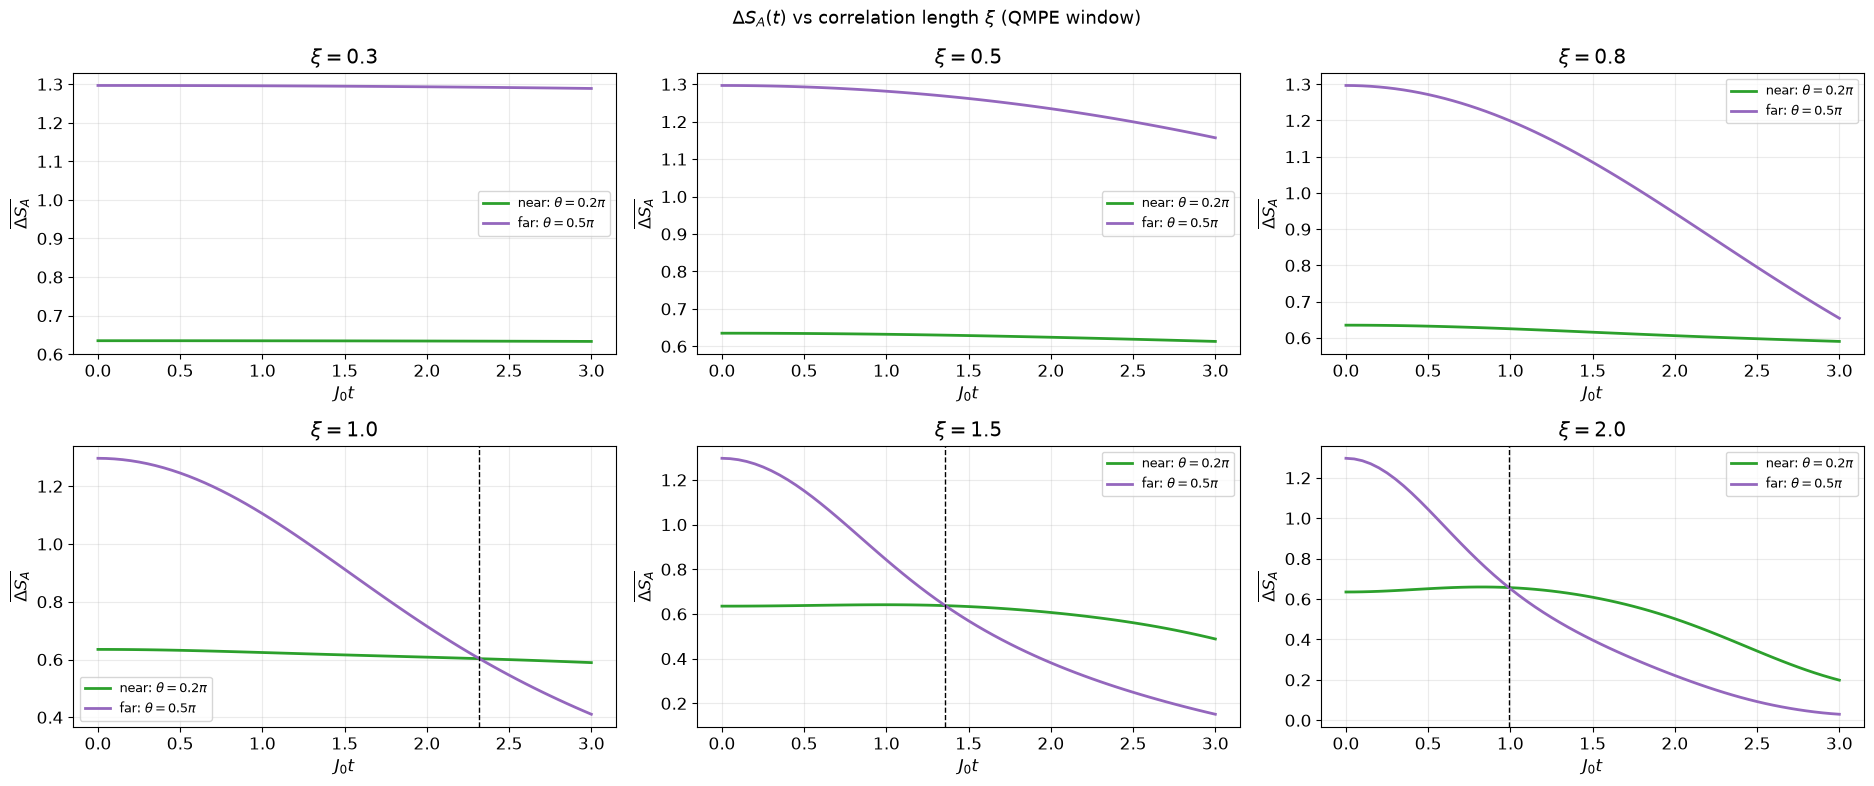

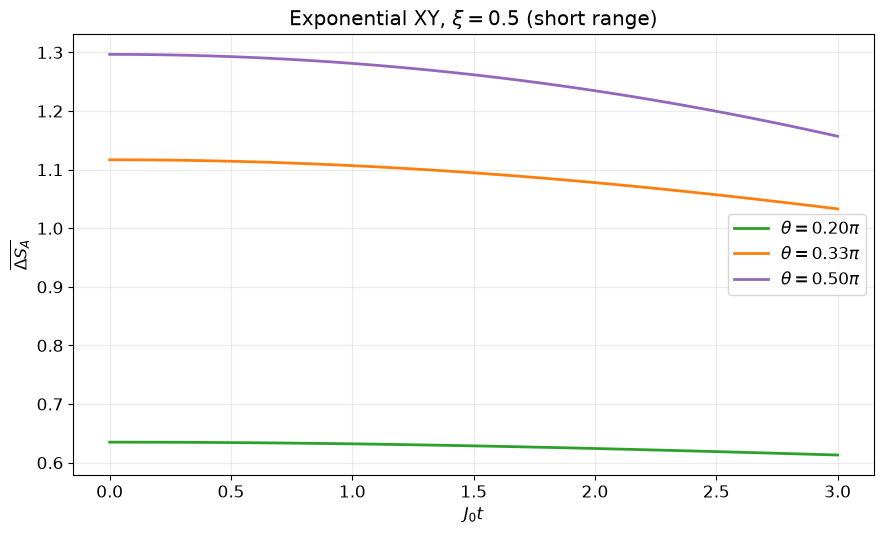

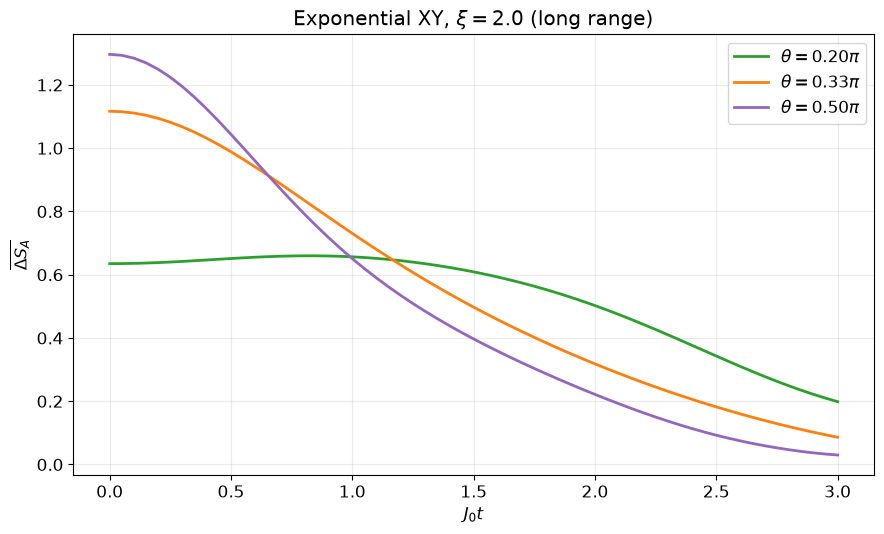

In [ ]:
def coupling_exponential1(N, J0, xi):
    # Exponential coupling:  
    J = np.zeros((N, N))
    for i in range(N):
        for j in range(i + 1, N):
            d = j - i
            J[i, j] = J[j, i] = J0 * np.exp(-d/ xi)
    return J
# ----------------------------------------------------------------------
# Stage II -- scan over the exponential correlation length xi
# ----------------------------------------------------------------------
xis = [0.3, 0.5, 0.8, 1.0, 1.5, 2.0]

xi_summary = {}
xi_scan = []
for xi in xis:
    J = coupling_exponential1(N, J0, xi)
    H = build_XY(N, J, h_zero, Sx, Sy, Sz)
    res = run_quench(H, thetas, tlist, subsystems, charge_projectors, N)
    ana = qmpe_crossing(tlist, res[theta_far]["EA_mean"],
                        res[theta_near]["EA_mean"],
                        t_qmpe_max, crossing_epsilon, min_negative_points)
    xi_summary[xi] = (res, ana)
    xi_scan.append((rf"$\xi={xi:.1f}$",
                    res[theta_near]["EA_mean"],
                    res[theta_far]["EA_mean"], ana["tcross"]))
    print(f"xi = {xi:.1f}:  t_cross = {ana['tcross']}"
          f"  (crossing detector M = {ana['strength']:.4f})")

# Shortening xi suppresses the crossing: read directly from Delta S_A(t).
plot_EA_grid(xi_scan, tlist, tlim=t_qmpe_max, ncols=3,
             suptitle=r"$\Delta S_A(t)$ vs correlation length $\xi$ (QMPE window)")

# Compare a short-range and a long-range case side by side.
plot_EA(tlist, xi_summary[0.5][0], tlim=t_qmpe_max,
        title=r"Exponential XY, $\xi=0.5$ (short range)")
plot_EA(tlist, xi_summary[2.0][0], tlim=t_qmpe_max,
        title=r"Exponential XY, $\xi=2.0$ (long range)")


---
## Stage III -- XY + disorder: localization suppresses the QMPE

Static transverse disorder $h_i\in[0,W]$ (uniform, in units of $J_0$) is
added to the power-law XY chain ($\alpha=1$). For **weak** disorder
($W\lesssim 3$) the QMPE survives; for **strong** disorder ($W\gtrsim 6$)
localization removes the crossing. Results are averaged over disorder
realizations.

> **Note on units.** The paper quotes the experimental light-shift strengths
> $w=6$ (weak) and $w=14$ (strong), whose absolute on-site fields are defined
> in its Supplemental Material. Here $W$ is the on-site-field width in units
> of $J_0$ (workflow.md's $W$), which directly controls the localization
> physics; the qualitative behavior of paper Fig. 2 is reproduced.


W = 1.0:  t_cross = 0.6431747270546555  (crossing detector M = 0.2503)
W = 2.0:  t_cross = 0.661153248316088  (crossing detector M = 0.2426)
W = 4.0:  t_cross = 0.8932899730948742  (crossing detector M = 0.1404)
W = 6.0:  t_cross = None  (crossing detector M = 0.0000)


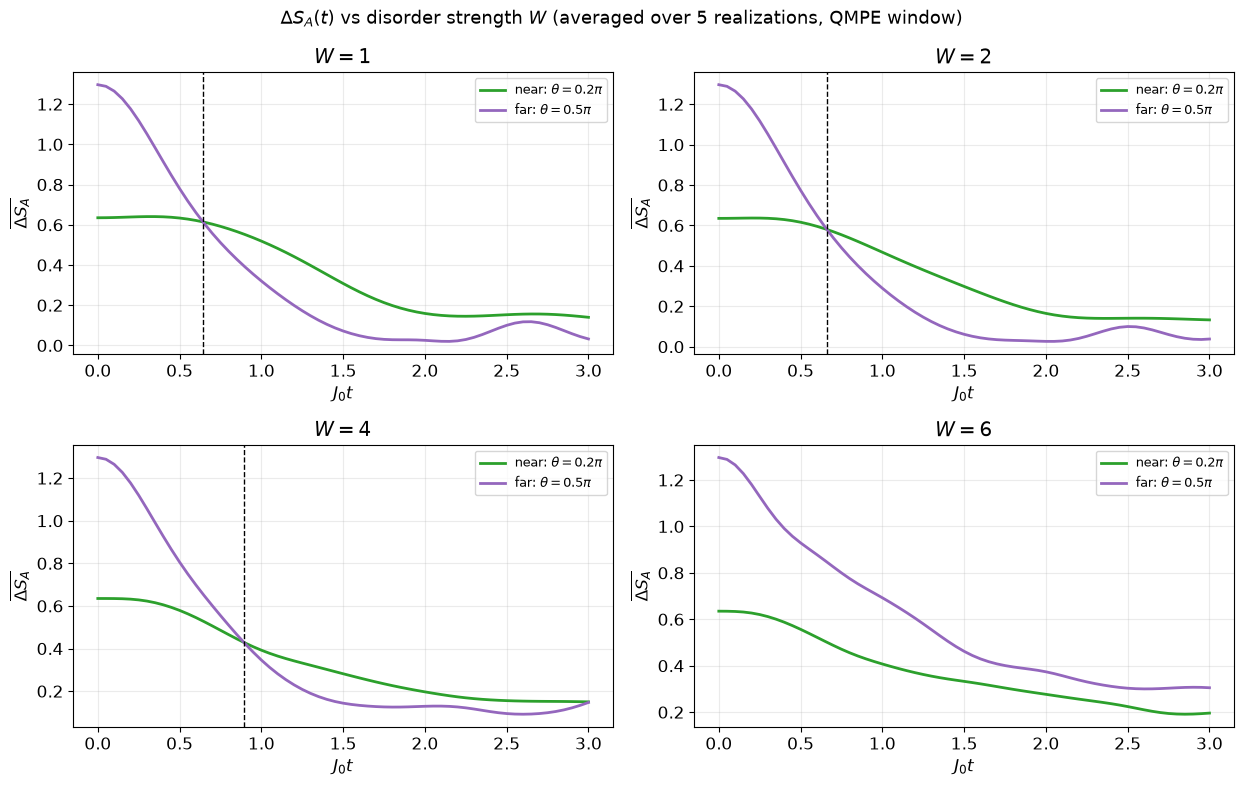

In [ ]:
# ----------------------------------------------------------------------
# Stage III -- disorder scan: weak -> strong, averaged over realizations
# ----------------------------------------------------------------------
W_grid = [1.0, 2.0, 4.0, 6.0]
n_real = 5

theta_pair = [theta_near, theta_far]

disorder_means = {}   # W -> (EA_near_mean, EA_far_mean)
disorder_scan = []

for W in W_grid:
    EA_far_list, EA_near_list = [], []
    for seed in range(n_real):
        h = onsite_disorder(N, W, seed=seed)
        H = build_XY(N, J_pow, h, Sx, Sy, Sz)
        res = run_quench(H, theta_pair, tlist, subsystems,
                         charge_projectors, N)
        EA_far_list.append(res[theta_far]["EA_mean"])
        EA_near_list.append(res[theta_near]["EA_mean"])

    EA_far_mean = np.mean(EA_far_list, axis=0)
    EA_near_mean = np.mean(EA_near_list, axis=0)
    ana = qmpe_crossing(tlist, EA_far_mean, EA_near_mean,
                        t_qmpe_max, crossing_epsilon, min_negative_points)
    disorder_means[W] = (EA_near_mean, EA_far_mean)
    disorder_scan.append((f"$W={W:g}$",
                          EA_near_mean, EA_far_mean, ana["tcross"]))
    print(f"W = {W}:  t_cross = {ana['tcross']}"
          f"  (crossing detector M = {ana['strength']:.4f})")

# Strong disorder removes the crossing: read directly from Delta S_A(t).
plot_EA_grid(disorder_scan, tlist, tlim=t_qmpe_max,
             suptitle=r"$\Delta S_A(t)$ vs disorder strength $W$ "
                      f"(averaged over {n_real} realizations, QMPE window)")


### Stage IV  The plan for saving QME!
 
 

###  make the other subsystems into thermal bath.dissipation will accelarate mpemba?

###  i want to discuss more about the effect !dive into quasiparticles and quantum fluctations !

In [24]:
# ======================================================================
# Deterministic subsystem-centered z-field
#
# Control for random onsite disorder:
#
#   random:
#       h_i ~ Uniform[-W, W]
#
#   deterministic:
#       h_i follows a smooth profile centered on all subsystem sites
#
# The deterministic field is:
#   (1) zero mean
#   (2) RMS matched to Uniform[-W, W]
#
# so that W has the same RMS energy scale in both scans.
# ======================================================================

def subsystem_z_profile(N, W, subsystems, xi=2.0):

    # --------------------------------------------------------------
    # Union of all sites belonging to the four subsystems
    # --------------------------------------------------------------

    A_sites = np.unique(
        np.concatenate([
            np.asarray(A, dtype=int)
            for A in subsystems
        ])
    )

    sites = np.arange(N)

    # --------------------------------------------------------------
    # Distance to the nearest subsystem site
    #
    # d_i = 0 for every site inside any subsystem
    # --------------------------------------------------------------

    d = np.array([
        np.min(np.abs(i - A_sites))
        for i in sites
    ], dtype=float)

    # --------------------------------------------------------------
    # Raw spatial profile
    #
    # subsystem sites: g = 1
    # outside:         exponentially decreasing
    # --------------------------------------------------------------

    g = np.exp(-d / xi)

    # --------------------------------------------------------------
    # Remove uniform z-field component
    # --------------------------------------------------------------

    g = g - np.mean(g)

    # --------------------------------------------------------------
    # Normalize to unit RMS
    # --------------------------------------------------------------

    g_rms = np.sqrt(np.mean(g**2))

    if g_rms < 1e-14:
        raise ValueError("Spatial profile has zero variance.")

    g /= g_rms

    # --------------------------------------------------------------
    # Uniform[-W, W] has RMS = W / sqrt(3)
    #
    # Therefore deterministic field has exactly the same RMS.
    # --------------------------------------------------------------

    h = (W / np.sqrt(3.0)) * g

    return h

W = 1.0: t_cross = 0.4799094252672504  (crossing detector M = 0.3414)
W = 2.0: t_cross = 0.4501497893427218  (crossing detector M = 0.4242)
W = 4.0: t_cross = 1.0783565708710505  (crossing detector M = 0.1376)
W = 6.0: t_cross = 1.3251466767695566  (crossing detector M = 0.0874)


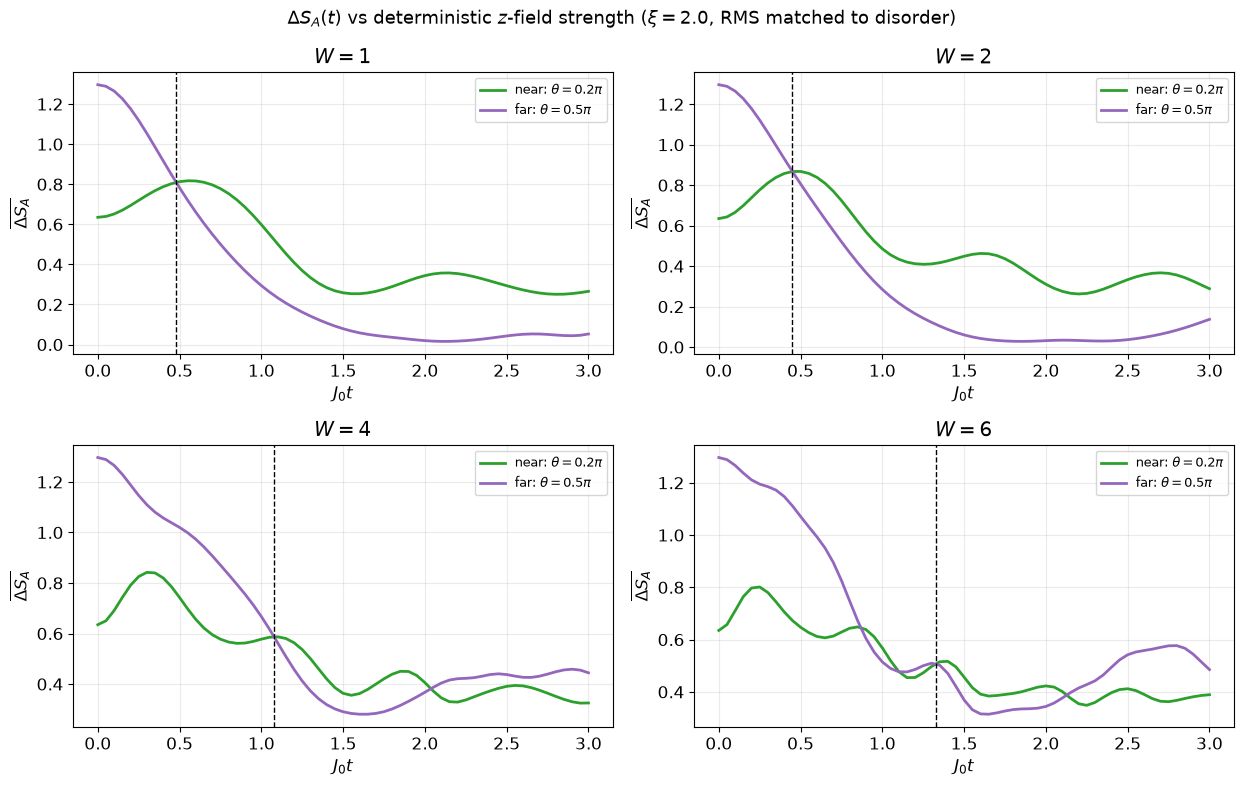

In [26]:
# ----------------------------------------------------------------------
# Stage IIIb -- deterministic inhomogeneous z-field
#
# Same W_grid as random disorder.
# RMS strength is matched to Uniform[-W, W].
# ----------------------------------------------------------------------

W_grid = [1.0, 2.0, 4.0, 6.0]

theta_pair = [theta_near, theta_far]

gradient_means = {}
gradient_scan = []

xi = 2.0

for W in W_grid:

    h = subsystem_z_profile(
        N,
        W,
        subsystems,
        xi=xi
    )

    H = build_XY(
        N,
        J_pow,
        h,
        Sx,
        Sy,
        Sz
    )

    res = run_quench(
        H,
        theta_pair,
        tlist,
        subsystems,
        charge_projectors,
        N
    )

    EA_far = res[theta_far]["EA_mean"]
    EA_near = res[theta_near]["EA_mean"]

    ana = qmpe_crossing(
        tlist,
        EA_far,
        EA_near,
        t_qmpe_max,
        crossing_epsilon,
        min_negative_points
    )

    gradient_means[W] = (
        EA_near,
        EA_far
    )

    gradient_scan.append(
        (
            rf"$W={W:g}$",
            EA_near,
            EA_far,
            ana["tcross"]
        )
    )

    print(
        f"W = {W}: "
        f"t_cross = {ana['tcross']}  "
        f"(crossing detector M = {ana['strength']:.4f})"
    )


plot_EA_grid(
    gradient_scan,
    tlist,
    tlim=t_qmpe_max,
    suptitle=(
        rf"$\Delta S_A(t)$ vs deterministic $z$-field strength "
        rf"($\xi={xi}$, RMS matched to disorder)"
    )
)


Exponential profile: W = 4
xi =  0.50   t_cross = 0.8438712211575916   M = 0.147398   roughness = 1.806051
xi =  1.00   t_cross = 0.9514464275143238   M = 0.124418   roughness = 1.596577
xi =  2.00   t_cross = 1.0783565708710505   M = 0.137610   roughness = 1.482068
xi =  4.00   t_cross = 1.125970849352907   M = 0.163975   roughness = 1.457286
xi =  8.00   t_cross = 1.1451898241023575   M = 0.202644   roughness = 1.460754

Exponential profile: W = 6
xi =  0.50   t_cross = 1.0165779187102928   M = 0.121169   roughness = 2.709076
xi =  1.00   t_cross = 1.1875503476822138   M = 0.094269   roughness = 2.394866
xi =  2.00   t_cross = 1.3251466767695566   M = 0.087365   roughness = 2.223102
xi =  4.00   t_cross = 0.9375212153665371   M = 0.139654   roughness = 2.185928
xi =  8.00   t_cross = 0.9776451691904728   M = 0.171627   roughness = 2.191130


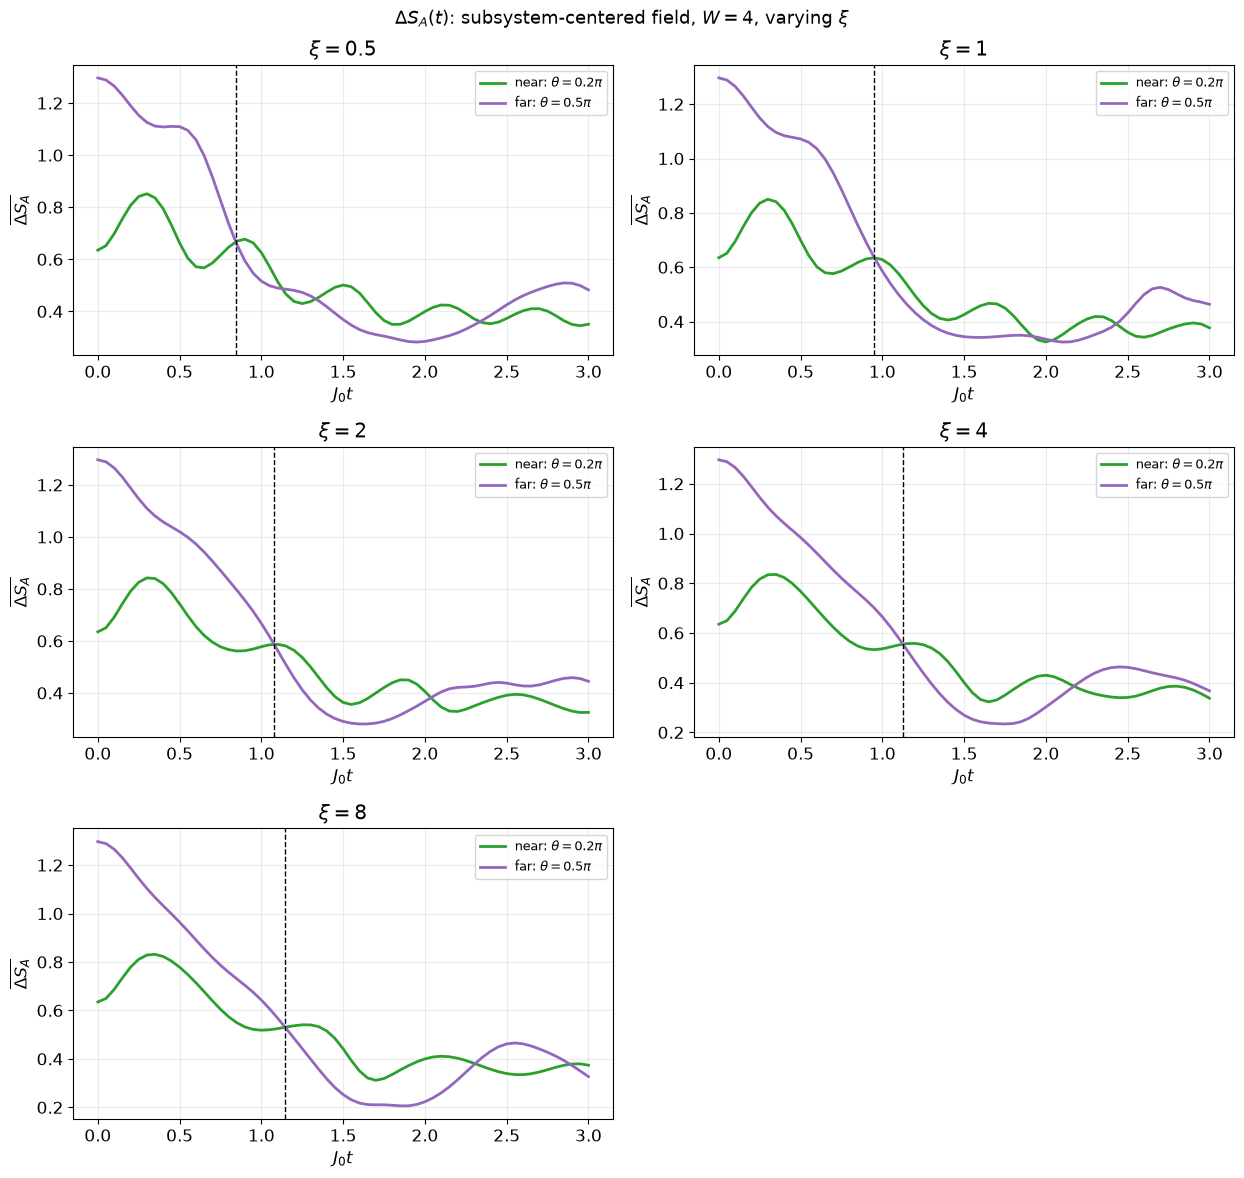

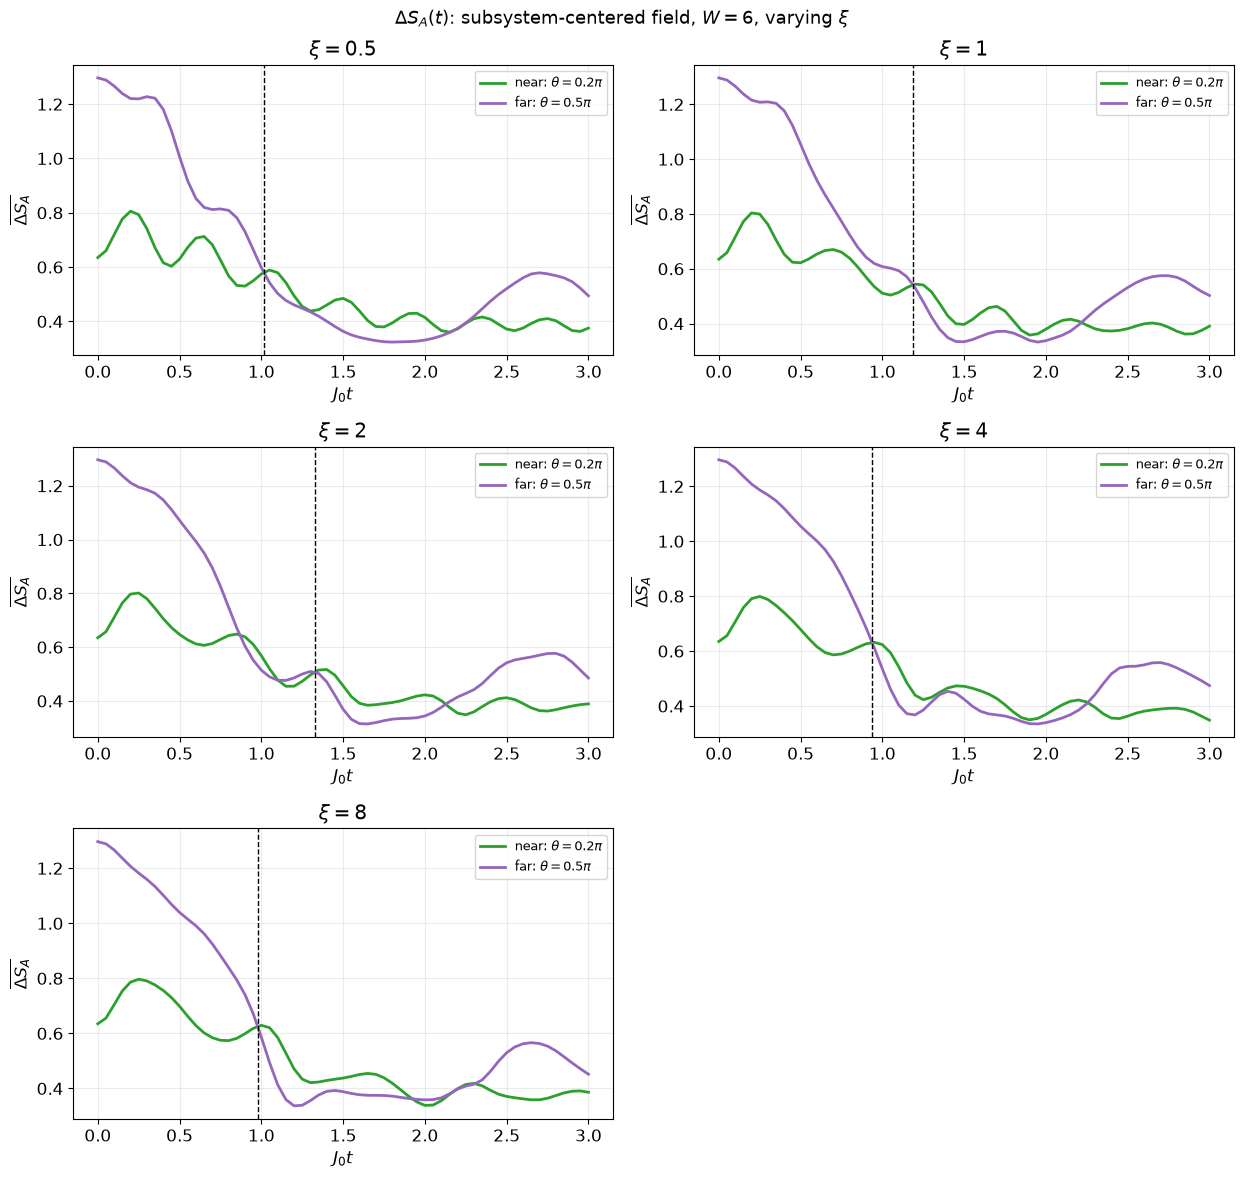

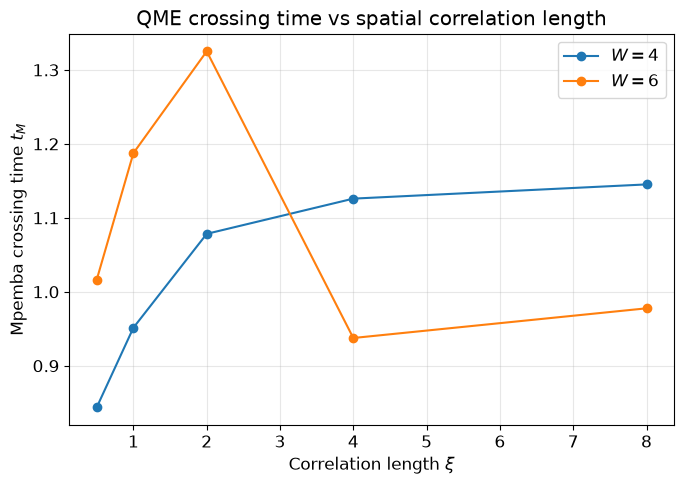

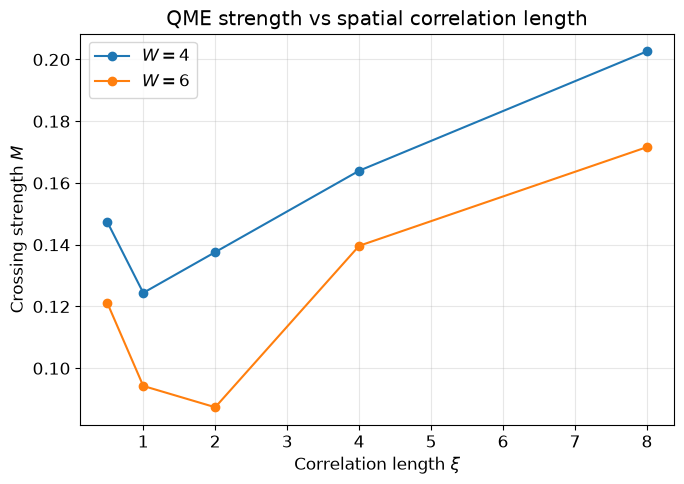

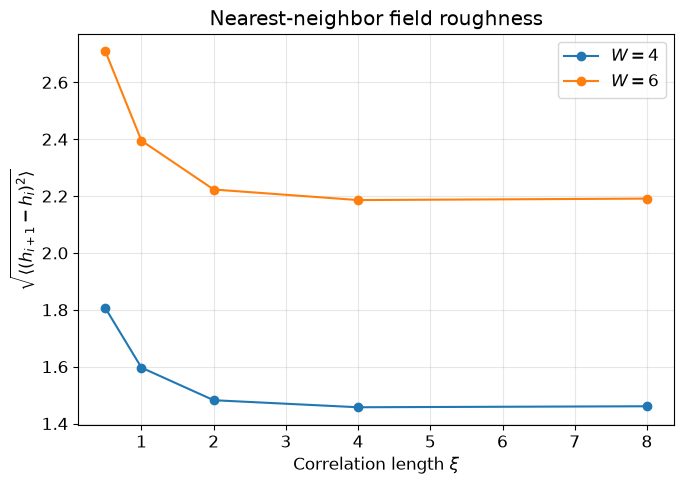

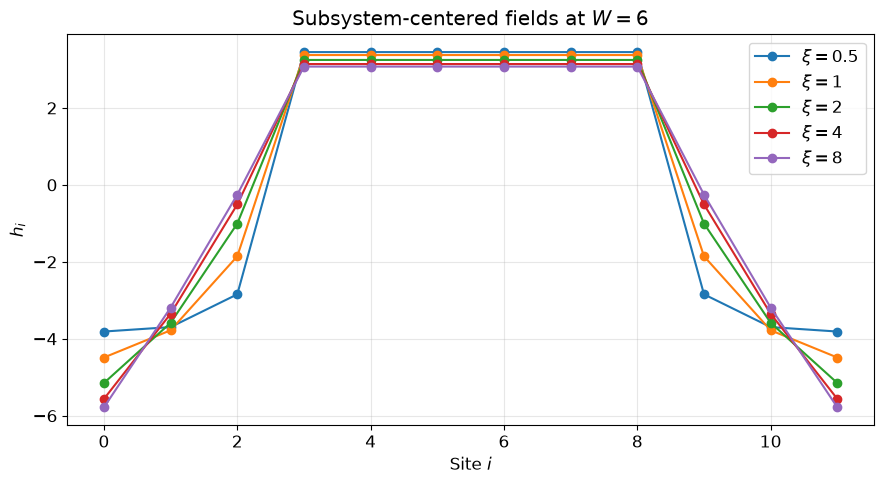


Single Fourier mode: W = 4
m =   1   q/pi = 0.1667   t_cross = None   M = 0.000000   roughness = 1.241601
m =   2   q/pi = 0.3333   t_cross = None   M = 0.082931   roughness = 2.361304
m =   3   q/pi = 0.5000   t_cross = 1.85674909622517   M = 0.137626   roughness = 3.265986
m =   4   q/pi = 0.6667   t_cross = 1.3958826058389529   M = 0.168117   roughness = 3.908034
m =   5   q/pi = 0.8333   t_cross = None   M = 0.000000   roughness = 4.282198
m =   6   q/pi = 1.0000   t_cross = 2.6956249882409096   M = 0.046614   roughness = 4.618802

Single Fourier mode: W = 6
m =   1   q/pi = 0.1667   t_cross = None   M = 0.000000   roughness = 1.862401
m =   2   q/pi = 0.3333   t_cross = 2.3794361153654795   M = 0.139676   roughness = 3.541956
m =   3   q/pi = 0.5000   t_cross = None   M = 0.020777   roughness = 4.898979
m =   4   q/pi = 0.6667   t_cross = 1.4317570486222284   M = 0.194779   roughness = 5.862051
m =   5   q/pi = 0.8333   t_cross = None   M = 0.000000   roughness = 6.423296
m =   6

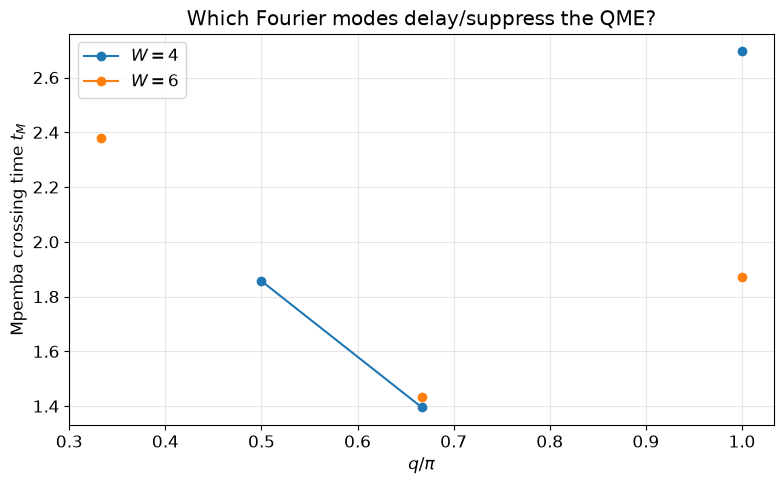

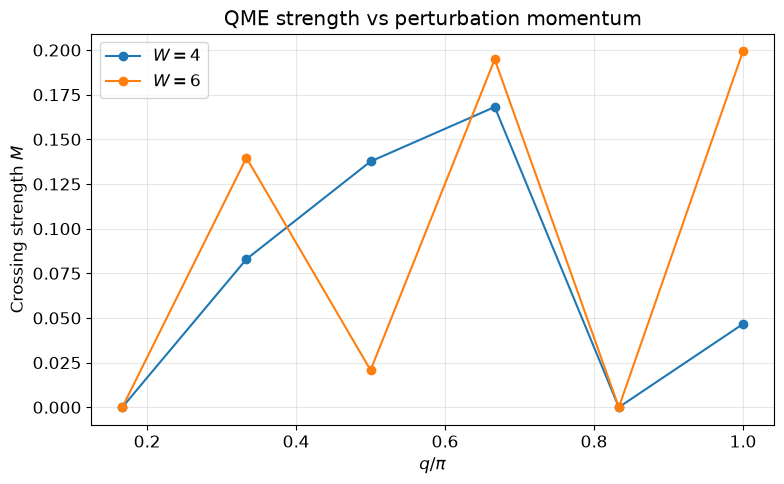

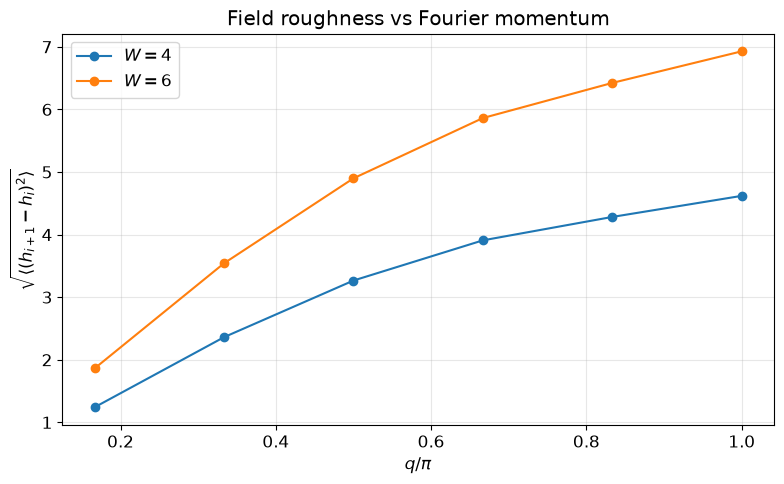

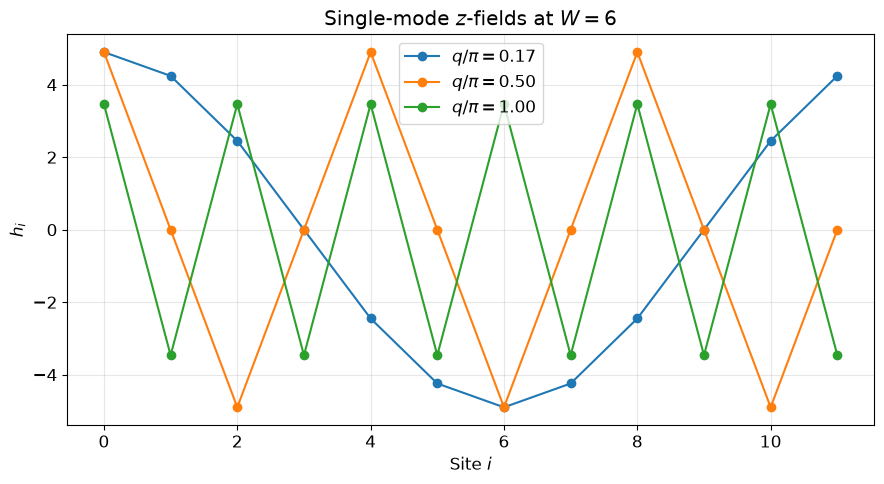

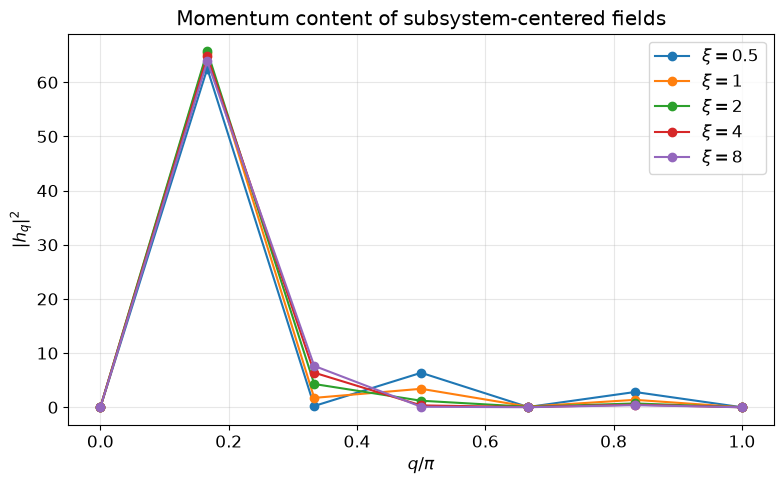

In [27]:
# ======================================================================
# Stage IV -- Spatial-correlation / Fourier-content study of the QME
#
# Goal:
#
#   Compare perturbations with the SAME:
#
#       <h_i> = 0
#
#   and
#
#       RMS(h_i) = W / sqrt(3)
#
#   but DIFFERENT spatial structures.
#
#
# We study:
#
#   A. subsystem-centered exponential field
#
#          g_i = exp[-d(i,A)/xi]
#
#      and scan:
#
#          (W, xi)
#
#
#   B. single Fourier-mode field
#
#          h_i ~ cos(q i + phi)
#
#      and scan:
#
#          (W, q)
#
#
# Observables:
#
#       t_M      = Mpemba crossing time
#       M        = crossing strength
#
# ======================================================================

import numpy as np
import matplotlib.pyplot as plt


# ======================================================================
# 1. Basic utility: zero-mean + RMS matching
# ======================================================================

def zero_mean_rms_match(profile, W):
    """
    Convert an arbitrary spatial profile into a zero-mean field with

        RMS(h) = W / sqrt(3),

    matching the RMS of Uniform[-W, W] disorder.

    Parameters
    ----------
    profile : array_like
        Raw spatial profile.

    W : float
        Disorder-equivalent strength.

    Returns
    -------
    h : ndarray
        Zero-mean, RMS-matched onsite z-field.
    """

    g = np.asarray(profile, dtype=float).copy()

    # Remove uniform q=0 component
    g -= np.mean(g)

    rms = np.sqrt(np.mean(g**2))

    if rms < 1e-14:
        raise ValueError(
            "The profile has zero spatial variance after "
            "subtracting its mean."
        )

    # Unit RMS
    g /= rms

    # Uniform[-W,W] has RMS W/sqrt(3)
    h = (W / np.sqrt(3.0)) * g

    return h


# ======================================================================
# 2. Subsystem-centered exponential field
# ======================================================================

def subsystem_exponential_field(N, W, subsystems, xi):
    """
    Construct

        g_i = exp[-d(i,A)/xi]

    where A is the union of all subsystem sites and

        d(i,A) = min_{j in A} |i-j|.

    Every subsystem site therefore has raw profile g_i = 1.

    The final field is shifted to zero mean and RMS matched to
    Uniform[-W,W].
    """

    if xi <= 0:
        raise ValueError("xi must be positive.")

    # Union of all subsystem sites
    A_sites = np.unique(
        np.concatenate([
            np.asarray(A, dtype=int)
            for A in subsystems
        ])
    )

    sites = np.arange(N)

    # Distance to nearest subsystem site
    d = np.array([
        np.min(np.abs(i - A_sites))
        for i in sites
    ], dtype=float)

    # Raw correlated profile
    profile = np.exp(-d / xi)

    # Zero mean + RMS match
    h = zero_mean_rms_match(profile, W)

    return h


# ======================================================================
# 3. Single Fourier-mode field
# ======================================================================

def sinusoidal_z_field(N, W, q, phi=0.0):
    """
    Single spatial Fourier mode:

        g_i = cos(q i + phi)

    followed by zero-mean and RMS matching.

    For the discrete momenta

        q_m = 2*pi*m/N,

    the mean is already zero for m != 0, but we subtract it
    numerically anyway.
    """

    sites = np.arange(N)

    profile = np.cos(q * sites + phi)

    return zero_mean_rms_match(profile, W)


# ======================================================================
# 4. Optional diagnostic: nearest-neighbor field roughness
# ======================================================================

def nearest_neighbor_roughness(h):
    """
    RMS nearest-neighbor field difference:

        delta_h_nn =
            sqrt(mean[(h_{i+1} - h_i)^2])

    Open-chain definition.
    """

    h = np.asarray(h, dtype=float)

    return np.sqrt(
        np.mean(
            np.diff(h)**2
        )
    )


# ======================================================================
# 5. Generic function for running ONE deterministic field
# ======================================================================

def analyze_field(
    h,
    theta_pair,
    tlist,
    subsystems,
    charge_projectors,
    N,
    J_pow,
    Sx,
    Sy,
    Sz,
    theta_near,
    theta_far,
    t_qmpe_max,
    crossing_epsilon,
    min_negative_points
):
    """
    Run the quench for one deterministic onsite z-field and return:

        EA_near
        EA_far
        t_cross
        strength
        roughness
    """

    H = build_XY(
        N,
        J_pow,
        h,
        Sx,
        Sy,
        Sz
    )

    res = run_quench(
        H,
        theta_pair,
        tlist,
        subsystems,
        charge_projectors,
        N
    )

    EA_near = res[theta_near]["EA_mean"]
    EA_far  = res[theta_far]["EA_mean"]

    ana = qmpe_crossing(
        tlist,
        EA_far,
        EA_near,
        t_qmpe_max,
        crossing_epsilon,
        min_negative_points
    )

    return {
        "EA_near": EA_near,
        "EA_far": EA_far,
        "tcross": ana["tcross"],
        "strength": ana["strength"],
        "roughness": nearest_neighbor_roughness(h),
        "h": np.asarray(h)
    }


# ======================================================================
# 6. Common settings
# ======================================================================

theta_pair = [
    theta_near,
    theta_far
]

# Start with the physically interesting strong-field region.
# You can add W=1,2 later if desired.
W_corr_grid = [
    4.0,
    6.0
]

# Spatial correlation lengths
xi_grid = [
    0.5,
    1.0,
    2.0,
    4.0,
    8.0
]


# ======================================================================
# 7. EXPONENTIAL PROFILE: scan (W, xi)
# ======================================================================

xi_results = {}

for W in W_corr_grid:

    xi_results[W] = {}

    print("\n" + "=" * 70)
    print(f"Exponential profile: W = {W:g}")
    print("=" * 70)

    for xi in xi_grid:

        h = subsystem_exponential_field(
            N,
            W,
            subsystems,
            xi
        )

        out = analyze_field(
            h=h,
            theta_pair=theta_pair,
            tlist=tlist,
            subsystems=subsystems,
            charge_projectors=charge_projectors,
            N=N,
            J_pow=J_pow,
            Sx=Sx,
            Sy=Sy,
            Sz=Sz,
            theta_near=theta_near,
            theta_far=theta_far,
            t_qmpe_max=t_qmpe_max,
            crossing_epsilon=crossing_epsilon,
            min_negative_points=min_negative_points
        )

        xi_results[W][xi] = out

        print(
            f"xi = {xi:5.2f}   "
            f"t_cross = {out['tcross']}   "
            f"M = {out['strength']:.6f}   "
            f"roughness = {out['roughness']:.6f}"
        )


# ======================================================================
# 8. Plot EA curves for the xi scan
# ======================================================================

for W in W_corr_grid:

    scan_for_plot = []

    for xi in xi_grid:

        out = xi_results[W][xi]

        scan_for_plot.append(
            (
                rf"$\xi={xi:g}$",
                out["EA_near"],
                out["EA_far"],
                out["tcross"]
            )
        )

    plot_EA_grid(
        scan_for_plot,
        tlist,
        tlim=t_qmpe_max,
        suptitle=(
            rf"$\Delta S_A(t)$: subsystem-centered field, "
            rf"$W={W:g}$, varying $\xi$"
        )
    )


# ======================================================================
# 9. Extract t_M(W,xi) and M(W,xi)
# ======================================================================

tM_xi = np.full(
    (len(W_corr_grid), len(xi_grid)),
    np.nan
)

M_xi = np.full_like(
    tM_xi,
    np.nan
)

roughness_xi = np.full_like(
    tM_xi,
    np.nan
)

for iW, W in enumerate(W_corr_grid):

    for ix, xi in enumerate(xi_grid):

        out = xi_results[W][xi]

        if out["tcross"] is not None:
            tM_xi[iW, ix] = out["tcross"]

        M_xi[iW, ix] = out["strength"]

        roughness_xi[iW, ix] = out["roughness"]


# ======================================================================
# 10. Plot t_M versus xi
# ======================================================================

plt.figure(figsize=(7, 5))

for iW, W in enumerate(W_corr_grid):

    plt.plot(
        xi_grid,
        tM_xi[iW],
        "o-",
        label=rf"$W={W:g}$"
    )

plt.xlabel(r"Correlation length $\xi$")
plt.ylabel(r"Mpemba crossing time $t_M$")
plt.title(
    r"QME crossing time vs spatial correlation length"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ======================================================================
# 11. Plot crossing strength M versus xi
# ======================================================================

plt.figure(figsize=(7, 5))

for iW, W in enumerate(W_corr_grid):

    plt.plot(
        xi_grid,
        M_xi[iW],
        "o-",
        label=rf"$W={W:g}$"
    )

plt.xlabel(r"Correlation length $\xi$")
plt.ylabel(r"Crossing strength $M$")
plt.title(
    r"QME strength vs spatial correlation length"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ======================================================================
# 12. Plot field roughness versus xi
# ======================================================================

plt.figure(figsize=(7, 5))

for iW, W in enumerate(W_corr_grid):

    plt.plot(
        xi_grid,
        roughness_xi[iW],
        "o-",
        label=rf"$W={W:g}$"
    )

plt.xlabel(r"Correlation length $\xi$")
plt.ylabel(
    r"$\sqrt{\langle(h_{i+1}-h_i)^2\rangle}$"
)
plt.title(
    r"Nearest-neighbor field roughness"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ======================================================================
# 13. Visualize exponential spatial profiles
#
# Important sanity check.
# ======================================================================

W_show = 6.0

plt.figure(figsize=(9, 5))

for xi in xi_grid:

    h = subsystem_exponential_field(
        N,
        W_show,
        subsystems,
        xi
    )

    plt.plot(
        np.arange(N),
        h,
        "o-",
        label=rf"$\xi={xi:g}$"
    )

plt.xlabel("Site $i$")
plt.ylabel(r"$h_i$")
plt.title(
    rf"Subsystem-centered fields at $W={W_show:g}$"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ======================================================================
# 14. FOURIER-MODE SCAN
#
# q_m = 2*pi*m/N
#
# q = 0 is excluded because after removing the uniform component
# the profile vanishes identically.
#
# For a real cosine:
#
#     q and 2*pi-q
#
# contain equivalent spatial wavelengths, so it is sufficient to
# scan approximately 0 < q <= pi.
# ======================================================================

m_max = N // 2

m_grid = np.arange(
    1,
    m_max + 1
)

q_grid = (
    2.0 * np.pi * m_grid / N
)

q_results = {}


# ======================================================================
# 15. Scan (W,q)
# ======================================================================

for W in W_corr_grid:

    q_results[W] = {}

    print("\n" + "=" * 70)
    print(f"Single Fourier mode: W = {W:g}")
    print("=" * 70)

    for m, q in zip(m_grid, q_grid):

        h = sinusoidal_z_field(
            N,
            W,
            q,
            phi=0.0
        )

        out = analyze_field(
            h=h,
            theta_pair=theta_pair,
            tlist=tlist,
            subsystems=subsystems,
            charge_projectors=charge_projectors,
            N=N,
            J_pow=J_pow,
            Sx=Sx,
            Sy=Sy,
            Sz=Sz,
            theta_near=theta_near,
            theta_far=theta_far,
            t_qmpe_max=t_qmpe_max,
            crossing_epsilon=crossing_epsilon,
            min_negative_points=min_negative_points
        )

        q_results[W][m] = out

        print(
            f"m = {m:3d}   "
            f"q/pi = {q / np.pi:.4f}   "
            f"t_cross = {out['tcross']}   "
            f"M = {out['strength']:.6f}   "
            f"roughness = {out['roughness']:.6f}"
        )


# ======================================================================
# 16. Extract t_M(W,q), M(W,q), roughness
# ======================================================================

tM_q = np.full(
    (len(W_corr_grid), len(q_grid)),
    np.nan
)

M_q = np.full_like(
    tM_q,
    np.nan
)

roughness_q = np.full_like(
    tM_q,
    np.nan
)

for iW, W in enumerate(W_corr_grid):

    for iq, m in enumerate(m_grid):

        out = q_results[W][m]

        if out["tcross"] is not None:
            tM_q[iW, iq] = out["tcross"]

        M_q[iW, iq] = out["strength"]

        roughness_q[iW, iq] = out["roughness"]


# ======================================================================
# 17. Plot t_M versus q
# ======================================================================

plt.figure(figsize=(8, 5))

for iW, W in enumerate(W_corr_grid):

    plt.plot(
        q_grid / np.pi,
        tM_q[iW],
        "o-",
        label=rf"$W={W:g}$"
    )

plt.xlabel(r"$q/\pi$")
plt.ylabel(r"Mpemba crossing time $t_M$")
plt.title(
    r"Which Fourier modes delay/suppress the QME?"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ======================================================================
# 18. Plot M versus q
# ======================================================================

plt.figure(figsize=(8, 5))

for iW, W in enumerate(W_corr_grid):

    plt.plot(
        q_grid / np.pi,
        M_q[iW],
        "o-",
        label=rf"$W={W:g}$"
    )

plt.xlabel(r"$q/\pi$")
plt.ylabel(r"Crossing strength $M$")
plt.title(
    r"QME strength vs perturbation momentum"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ======================================================================
# 19. Plot roughness versus q
# ======================================================================

plt.figure(figsize=(8, 5))

for iW, W in enumerate(W_corr_grid):

    plt.plot(
        q_grid / np.pi,
        roughness_q[iW],
        "o-",
        label=rf"$W={W:g}$"
    )

plt.xlabel(r"$q/\pi$")
plt.ylabel(
    r"$\sqrt{\langle(h_{i+1}-h_i)^2\rangle}$"
)
plt.title(
    r"Field roughness vs Fourier momentum"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ======================================================================
# 20. Visualize selected Fourier modes
# ======================================================================

W_show = 6.0

# Pick representative wavelengths
selected_m = sorted(
    set([
        1,
        max(1, N // 8),
        max(1, N // 4),
        max(1, N // 2)
    ])
)

plt.figure(figsize=(9, 5))

for m in selected_m:

    q = 2.0 * np.pi * m / N

    h = sinusoidal_z_field(
        N,
        W_show,
        q
    )

    plt.plot(
        np.arange(N),
        h,
        "o-",
        label=rf"$q/\pi={q / np.pi:.2f}$"
    )

plt.xlabel("Site $i$")
plt.ylabel(r"$h_i$")
plt.title(
    rf"Single-mode $z$-fields at $W={W_show:g}$"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ======================================================================
# 21. Fourier spectrum of exponential profiles
#
# This lets us directly see how xi changes the momentum content.
# ======================================================================

W_show = 6.0

plt.figure(figsize=(8, 5))

for xi in xi_grid:

    h = subsystem_exponential_field(
        N,
        W_show,
        subsystems,
        xi
    )

    # Orthonormal-ish convention; only relative spectral weight matters
    hq = np.fft.rfft(h) / np.sqrt(N)

    q_fft = (
        2.0 * np.pi
        * np.fft.rfftfreq(N)
    )

    spectral_weight = np.abs(hq)**2

    plt.plot(
        q_fft / np.pi,
        spectral_weight,
        "o-",
        label=rf"$\xi={xi:g}$"
    )

plt.xlabel(r"$q/\pi$")
plt.ylabel(r"$|h_q|^2$")
plt.title(
    r"Momentum content of subsystem-centered fields"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()